## Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
plt.rcParams['figure.figsize']=[20,10]
from warnings import filterwarnings
filterwarnings('ignore')

## Data reading

In [2]:
pd.set_option('display.max_columns',60)

In [3]:
df = pd.read_csv(r"d07_text_station_5min_2026_01_01.txt")

In [4]:
df.columns = [
    # ----- Station Level (12 columns) -----
    "Timestamp",
    "Station",
    "District",
    "Freeway",
    "Direction",
    "Lane_Type",
    "Station_Length",
    "Samples",
    "Percent_Observed",
    "Total_Flow",
    "Avg_Occupancy",
    "Avg_Speed",

    # ----- Lane 1 -----
    "Lane1_Samples",
    "Lane1_Flow",
    "Lane1_Avg_Occupancy",
    "Lane1_Avg_Speed",

    # ----- Lane 2 -----
    "Lane2_Samples",
    "Lane2_Flow",
    "Lane2_Avg_Occupancy",
    "Lane2_Avg_Speed",

    # ----- Lane 3 -----
    "Lane3_Samples",
    "Lane3_Flow",
    "Lane3_Avg_Occupancy",
    "Lane3_Avg_Speed",

    # ----- Lane 4 -----
    "Lane4_Samples",
    "Lane4_Flow",
    "Lane4_Avg_Occupancy",
    "Lane4_Avg_Speed",

    # ----- Lane 5 -----
    "Lane5_Samples",
    "Lane5_Flow",
    "Lane5_Avg_Occupancy",
    "Lane5_Avg_Speed",

    # ----- Lane 6 -----
    "Lane6_Samples",
    "Lane6_Flow",
    "Lane6_Avg_Occupancy",
    "Lane6_Avg_Speed",

    # ----- Lane 7 -----
    "Lane7_Samples",
    "Lane7_Flow",
    "Lane7_Avg_Occupancy",
    "Lane7_Avg_Speed",

    # ----- Lane 8 -----
    "Lane8_Samples",
    "Lane8_Flow",
    "Lane8_Avg_Occupancy",
    "Lane8_Avg_Speed",

    # ----- Lane 9 -----
    "Lane9_Samples",
    "Lane9_Flow",
    "Lane9_Avg_Occupancy",
    "Lane9_Avg_Speed",

    # ----- Lane 10 -----
    "Lane10_Samples",
    "Lane10_Flow",
    "Lane10_Avg_Occupancy",
    "Lane10_Avg_Speed"
]

In [5]:
df.head()

,Timestamp,Station,District,Freeway,Direction,Lane_Type,Station_Length,Samples,Percent_Observed,Total_Flow,Avg_Occupancy,Avg_Speed,Lane1_Samples,Lane1_Flow,Lane1_Avg_Occupancy,Lane1_Avg_Speed,Lane2_Samples,Lane2_Flow,Lane2_Avg_Occupancy,Lane2_Avg_Speed,Lane3_Samples,Lane3_Flow,Lane3_Avg_Occupancy,Lane3_Avg_Speed,Lane4_Samples,Lane4_Flow,Lane4_Avg_Occupancy,Lane4_Avg_Speed,Lane5_Samples,Lane5_Flow,Lane5_Avg_Occupancy,Lane5_Avg_Speed,Lane6_Samples,Lane6_Flow,Lane6_Avg_Occupancy,Lane6_Avg_Speed,Lane7_Samples,Lane7_Flow,Lane7_Avg_Occupancy,Lane7_Avg_Speed,Lane8_Samples,Lane8_Flow,Lane8_Avg_Occupancy,Lane8_Avg_Speed,Lane9_Samples,Lane9_Flow,Lane9_Avg_Occupancy,Lane9_Avg_Speed,Lane10_Samples,Lane10_Flow,Lane10_Avg_Occupancy,Lane10_Avg_Speed
0,01/01/2026 00:00:00,715900,7,5,S,OR,NaN,0,0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
1,01/01/2026 00:00:00,715901,7,5,N,OR,NaN,0,0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
2,01/01/2026 00:00:00,715903,7,5,N,OR,NaN,0,0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
3,01/01/2026 00:00:00,715904,7,5,S,OR,NaN,0,0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
4,01/01/2026 00:00:00,715905,7,5,N,OR,NaN,0,0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0


## Five-Point Summary

In [6]:
df.shape

(1407743, 52)

The data has 1407743 rows and 52 columns in total

### Feature Engineering

In [7]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

Converting the time stamp column into Datetime Format

In [8]:
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month
df["Day_of_Week"] = df["Timestamp"].dt.dayofweek
df["Is_Weekend"] = df["Day_of_Week"].apply(lambda x: 'Yes' if x >= 5 else 'No')

In [9]:
df["Hour"]=df["Hour"].astype('object')
df["Day"]=df["Day"].astype('object')
df["Month"]=df["Month"].astype('object')
df["Day_of_Week"]=df["Day_of_Week"].astype('object')
df["Is_Weekend"]=df["Is_Weekend"].astype('object')

Extrcting the Hour,Day,Month,Day of the Week and whether it is a weekend or not from the Timestamp column for further analysis and chaning them into object class. We can drop the timestamp column

In [10]:
df.drop('Timestamp',axis=1,inplace=True)

### Data Type Intrepretation

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407743 entries, 0 to 1407742
Data columns (total 56 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Station               1407743 non-null  int64  
 1   District              1407743 non-null  int64  
 2   Freeway               1407743 non-null  int64  
 3   Direction             1407743 non-null  object 
 4   Lane_Type             1407743 non-null  object 
 5   Station_Length        803231 non-null   float64
 6   Samples               1407743 non-null  int64  
 7   Percent_Observed      1407743 non-null  int64  
 8   Total_Flow            921403 non-null   float64
 9   Avg_Occupancy         921403 non-null   float64
 10  Avg_Speed             803231 non-null   float64
 11  Lane1_Samples         1407455 non-null  float64
 12  Lane1_Flow            918776 non-null   float64
 13  Lane1_Avg_Occupancy   918776 non-null   float64
 14  Lane1_Avg_Speed       803231 non-n

### Missing Value Treatment

In [12]:
df.isnull().sum()

Station                       0
District                      0
Freeway                       0
Direction                     0
Lane_Type                     0
Station_Length           604512
Samples                       0
Percent_Observed              0
Total_Flow               486340
Avg_Occupancy            486340
Avg_Speed                604512
Lane1_Samples               288
Lane1_Flow               488967
Lane1_Avg_Occupancy      488967
Lane1_Avg_Speed          604512
Lane2_Samples                 0
Lane2_Flow               730656
Lane2_Avg_Occupancy      832337
Lane2_Avg_Speed          832337
Lane3_Samples            846720
Lane3_Flow                    0
Lane3_Avg_Occupancy      859392
Lane3_Avg_Speed          870912
Lane4_Samples            870912
Lane4_Flow               872640
Lane4_Avg_Occupancy           0
Lane4_Avg_Speed          965663
Lane5_Samples            966239
Lane5_Flow               966239
Lane5_Avg_Occupancy      966239
Lane5_Avg_Speed               0
Lane6_Sa

In [13]:
df.isnull().sum()/len(df)*100

Station                  0.000000
District                 0.000000
Freeway                  0.000000
Direction                0.000000
Lane_Type                0.000000
Station_Length          42.941929
Samples                  0.000000
Percent_Observed         0.000000
Total_Flow              34.547499
Avg_Occupancy           34.547499
Avg_Speed               42.941929
Lane1_Samples            0.020458
Lane1_Flow              34.734110
Lane1_Avg_Occupancy     34.734110
Lane1_Avg_Speed         42.941929
Lane2_Samples            0.000000
Lane2_Flow              51.902656
Lane2_Avg_Occupancy     59.125636
Lane2_Avg_Speed         59.125636
Lane3_Samples           60.147342
Lane3_Flow               0.000000
Lane3_Avg_Occupancy     61.047507
Lane3_Avg_Speed         61.865838
Lane4_Samples           61.865838
Lane4_Flow              61.988587
Lane4_Avg_Occupancy      0.000000
Lane4_Avg_Speed         68.596541
Lane5_Samples           68.637457
Lane5_Flow              68.637457
Lane5_Avg_Occu

There is a huge number of missing values evidently present in the data. We shall proceed with imputing the missing values

In [14]:
null_col=[]
for i in df.columns:
    if df[i].isnull().sum()/len(df)*100 > 90:
        null_col.append(i)

In [15]:
null_col

['Lane6_Samples',
 'Lane6_Flow',
 'Lane6_Avg_Occupancy',
 'Lane6_Avg_Speed',
 'Lane7_Flow',
 'Lane7_Avg_Occupancy',
 'Lane7_Avg_Speed',
 'Lane8_Samples',
 'Lane8_Avg_Occupancy',
 'Lane8_Avg_Speed',
 'Lane9_Samples',
 'Lane9_Flow',
 'Lane9_Avg_Speed',
 'Lane10_Samples',
 'Lane10_Flow',
 'Lane10_Avg_Occupancy']

In [16]:
df.drop(null_col,axis=1,inplace=True)

In [17]:
df.columns

Index(['Station', 'District', 'Freeway', 'Direction', 'Lane_Type',
       'Station_Length', 'Samples', 'Percent_Observed', 'Total_Flow',
       'Avg_Occupancy', 'Avg_Speed', 'Lane1_Samples', 'Lane1_Flow',
       'Lane1_Avg_Occupancy', 'Lane1_Avg_Speed', 'Lane2_Samples', 'Lane2_Flow',
       'Lane2_Avg_Occupancy', 'Lane2_Avg_Speed', 'Lane3_Samples', 'Lane3_Flow',
       'Lane3_Avg_Occupancy', 'Lane3_Avg_Speed', 'Lane4_Samples', 'Lane4_Flow',
       'Lane4_Avg_Occupancy', 'Lane4_Avg_Speed', 'Lane5_Samples', 'Lane5_Flow',
       'Lane5_Avg_Occupancy', 'Lane5_Avg_Speed', 'Lane7_Samples', 'Lane8_Flow',
       'Lane9_Avg_Occupancy', 'Lane10_Avg_Speed', 'Hour', 'Day', 'Month',
       'Day_of_Week', 'Is_Weekend'],
      dtype='object')

In [18]:
df.isnull().sum()/len(df)*100

Station                 0.000000
District                0.000000
Freeway                 0.000000
Direction               0.000000
Lane_Type               0.000000
Station_Length         42.941929
Samples                 0.000000
Percent_Observed        0.000000
Total_Flow             34.547499
Avg_Occupancy          34.547499
Avg_Speed              42.941929
Lane1_Samples           0.020458
Lane1_Flow             34.734110
Lane1_Avg_Occupancy    34.734110
Lane1_Avg_Speed        42.941929
Lane2_Samples           0.000000
Lane2_Flow             51.902656
Lane2_Avg_Occupancy    59.125636
Lane2_Avg_Speed        59.125636
Lane3_Samples          60.147342
Lane3_Flow              0.000000
Lane3_Avg_Occupancy    61.047507
Lane3_Avg_Speed        61.865838
Lane4_Samples          61.865838
Lane4_Flow             61.988587
Lane4_Avg_Occupancy     0.000000
Lane4_Avg_Speed        68.596541
Lane5_Samples          68.637457
Lane5_Flow             68.637457
Lane5_Avg_Occupancy    68.637457
Lane5_Avg_

In [19]:
def time_block(hour):
    if hour < 6:
        return "0-5"
    elif hour < 12:
        return "6-11"
    elif hour < 18:
        return "12-17"
    else:
        return "18-23"

df["Time_Block"] = df["Hour"].apply(time_block)

To deal with missing values, creating a column Time_block grouping the time into time intervals so that we can take the mean of the time groups and impute the missing values with its relevant time blocks mean value

In [20]:
numeric_cols = df.select_dtypes(include=['number']).columns

In [21]:
numeric_null_cols = [col for col in numeric_cols if df[col].isnull().sum() > 0]

In [22]:
for col in numeric_null_cols:
    df[col] = df.groupby('Time_Block')[col].transform(lambda x: x.fillna(x.mean()))

In [23]:
df.isnull().sum()

Station                0
District               0
Freeway                0
Direction              0
Lane_Type              0
Station_Length         0
Samples                0
Percent_Observed       0
Total_Flow             0
Avg_Occupancy          0
Avg_Speed              0
Lane1_Samples          0
Lane1_Flow             0
Lane1_Avg_Occupancy    0
Lane1_Avg_Speed        0
Lane2_Samples          0
Lane2_Flow             0
Lane2_Avg_Occupancy    0
Lane2_Avg_Speed        0
Lane3_Samples          0
Lane3_Flow             0
Lane3_Avg_Occupancy    0
Lane3_Avg_Speed        0
Lane4_Samples          0
Lane4_Flow             0
Lane4_Avg_Occupancy    0
Lane4_Avg_Speed        0
Lane5_Samples          0
Lane5_Flow             0
Lane5_Avg_Occupancy    0
Lane5_Avg_Speed        0
Lane7_Samples          0
Lane8_Flow             0
Lane9_Avg_Occupancy    0
Lane10_Avg_Speed       0
Hour                   0
Day                    0
Month                  0
Day_of_Week            0
Is_Weekend             0


### Data interpretation

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Station,1407743.0,746848.859548,25426.271826,715898.000,717399.000000,761492.000000,769006.500000,777829.0000
District,1407743.0,7.000000,0.000000,7.000,7.000000,7.000000,7.000000,7.0000
Freeway,1407743.0,182.420953,198.616577,2.000,23.000000,105.000000,210.000000,710.0000
Station_Length,1407743.0,0.602877,0.430092,0.009,0.440000,0.602876,0.602877,5.0000
Samples,1407743.0,5.795267,12.134781,0.000,0.000000,0.000000,10.000000,60.0000
Percent_Observed,1407743.0,18.926591,38.261438,0.000,0.000000,0.000000,0.000000,100.0000
Total_Flow,1407743.0,183.642006,150.827910,0.000,84.724540,144.000000,249.576737,1414.0000
Avg_Occupancy,1407743.0,0.062001,0.055168,0.000,0.022656,0.058992,0.080100,0.9989
Avg_Speed,1407743.0,62.130924,6.621652,3.000,60.572402,63.858894,65.700000,84.8000
Lane1_Samples,1407743.0,2.603020,4.381934,0.000,0.000000,0.000000,10.000000,10.0000


* High variation suggests fluctuating traffic patterns due to peak hours or incidents.
* Traffic volume changes significantly across time, indicating peak and off-peak periods.
* Occupancy is a strong indicator of congestion and correlates inversely with speed.
* Outliers exist in speed/flow
* Different lanes show different traffic behavior:
* Fast lanes → higher speed
* Slow lanes → congestion buildup

In [25]:
cat_col = df.select_dtypes(include='object').columns.to_list()

In [26]:
for i in cat_col:
    print(i)
    print(df[i].value_counts())
    print('___________________________________________')

Direction
Direction
S    371232
N    350495
W    344448
E    341568
Name: count, dtype: int64
___________________________________________
Lane_Type
Lane_Type
ML    551807
OR    311328
HV    251424
FR    224352
FF     60480
CD      8352
Name: count, dtype: int64
___________________________________________
Hour
Hour
12    58656
1     58656
22    58656
21    58656
20    58656
19    58656
18    58656
17    58656
16    58656
15    58656
14    58656
13    58656
23    58656
11    58656
10    58656
9     58656
8     58656
7     58656
6     58656
5     58656
4     58656
3     58656
2     58656
0     58655
Name: count, dtype: int64
___________________________________________
Day
Day
1    1407743
Name: count, dtype: int64
___________________________________________
Month
Month
1    1407743
Name: count, dtype: int64
___________________________________________
Day_of_Week
Day_of_Week
3    1407743
Name: count, dtype: int64
___________________________________________
Is_Weekend
Is_Weekend
No    14077

### Outlier Detection

In [27]:
iqr = df[numeric_cols].quantile(0.75)-df[numeric_cols].quantile(0.25)
low_whisk = df[numeric_cols].quantile(0.25)-(1.5*iqr)
upp_whisk = df[numeric_cols].quantile(0.75)+(1.5*iqr)

In [28]:
outliers = df[((df[numeric_cols]<low_whisk)|(df[numeric_cols]>upp_whisk)).any(axis=1)]
outliers

,Station,District,Freeway,Direction,Lane_Type,Station_Length,Samples,Percent_Observed,Total_Flow,Avg_Occupancy,Avg_Speed,Lane1_Samples,Lane1_Flow,Lane1_Avg_Occupancy,Lane1_Avg_Speed,Lane2_Samples,Lane2_Flow,Lane2_Avg_Occupancy,Lane2_Avg_Speed,Lane3_Samples,Lane3_Flow,Lane3_Avg_Occupancy,Lane3_Avg_Speed,Lane4_Samples,Lane4_Flow,Lane4_Avg_Occupancy,Lane4_Avg_Speed,Lane5_Samples,Lane5_Flow,Lane5_Avg_Occupancy,Lane5_Avg_Speed,Lane7_Samples,Lane8_Flow,Lane9_Avg_Occupancy,Lane10_Avg_Speed,Hour,Day,Month,Day_of_Week,Is_Weekend,Time_Block
15,715920,7,5,S,ML,1.150000,0,0,224.0,0.0395,70.000000,0.0,47.0,0.0280,75.900000,0,0.000000,68.000000,0.043500,72.000000,0,0.000000,60.000000,0.045300,68.400000,0,0.000000,49.000000,0.041200,63.700000,0,0,0,0,0,0,1,1,3,No,0-5
22,715929,7,5,S,ML,0.470000,0,0,181.0,0.0423,69.000000,0.0,38.0,0.0300,74.800000,0,0.000000,55.000000,0.046600,71.000000,0,0.000000,48.000000,0.048500,67.400000,0,0.000000,40.000000,0.044100,62.800000,0,0,0,0,0,0,1,1,3,No,0-5
23,715930,7,5,N,ML,0.505000,0,0,145.0,0.0307,69.200000,0.0,30.0,0.0218,75.000000,0,0.000000,44.000000,0.033800,71.200000,0,0.000000,39.000000,0.035200,67.600000,0,0.000000,32.000000,0.032000,63.000000,0,0,0,0,0,0,1,1,3,No,0-5
25,715933,7,5,N,ML,0.425000,0,0,145.0,0.0307,69.200000,0.0,30.0,0.0218,75.000000,0,0.000000,44.000000,0.033800,71.200000,0,0.000000,39.000000,0.035200,67.600000,0,0.000000,32.000000,0.032000,63.000000,0,0,0,0,0,0,1,1,3,No,0-5
28,715938,7,5,N,ML,0.545000,40,0,227.0,0.0448,72.800000,10.0,78.0,0.0637,76.200000,0,10.000000,68.000000,0.054300,70.600000,0,10.000000,54.000000,0.036800,75.800000,0,10.000000,27.000000,0.024300,62.800000,0,0,0,0,0,0,1,1,3,No,0-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407734,777781,7,5,N,ML,0.360000,0,0,169.0,0.5284,26.400000,0.0,34.0,0.5164,27.300000,0,0.000000,41.000000,0.538200,25.400000,0,0.000000,34.000000,0.567000,25.000000,0,0.000000,28.000000,0.537800,25.700000,0,0,0,0,0,23,1,1,3,No,18-23
1407738,777794,7,5,S,HV,2.645000,10,0,115.0,0.4893,23.600000,10.0,115.0,0.4893,23.600000,0,2.492208,78.066196,0.080141,65.401765,0,2.426069,69.729837,0.084737,61.621416,0,2.565273,61.934007,0.082252,58.760475,0,0,0,0,0,23,1,1,3,No,18-23
1407739,777795,7,5,N,HV,2.645000,10,100,3.0,0.0017,65.000000,10.0,3.0,0.0017,65.000000,1,2.492208,78.066196,0.080141,65.401765,0,2.426069,69.729837,0.084737,61.621416,0,2.565273,61.934007,0.082252,58.760475,0,0,0,0,0,23,1,1,3,No,18-23
1407740,777796,7,5,N,ML,0.350000,40,100,76.0,0.4338,57.500000,1.0,10.0,0.8661,45.400000,1,10.000000,20.000000,0.694800,50.500000,1,9.000000,20.000000,0.584400,44.000000,1,10.000000,24.000000,0.020700,79.200000,1,1,0,0,0,23,1,1,3,No,18-23


In [29]:
(outliers.shape[0]/len(df))*100

56.05042965939096

There is about 50% overall outliers in the data. We may not treat them as it may affect the precision and performance of the data so we will leave it as it is. If necessary we will deal with it later

## Univariate analysis


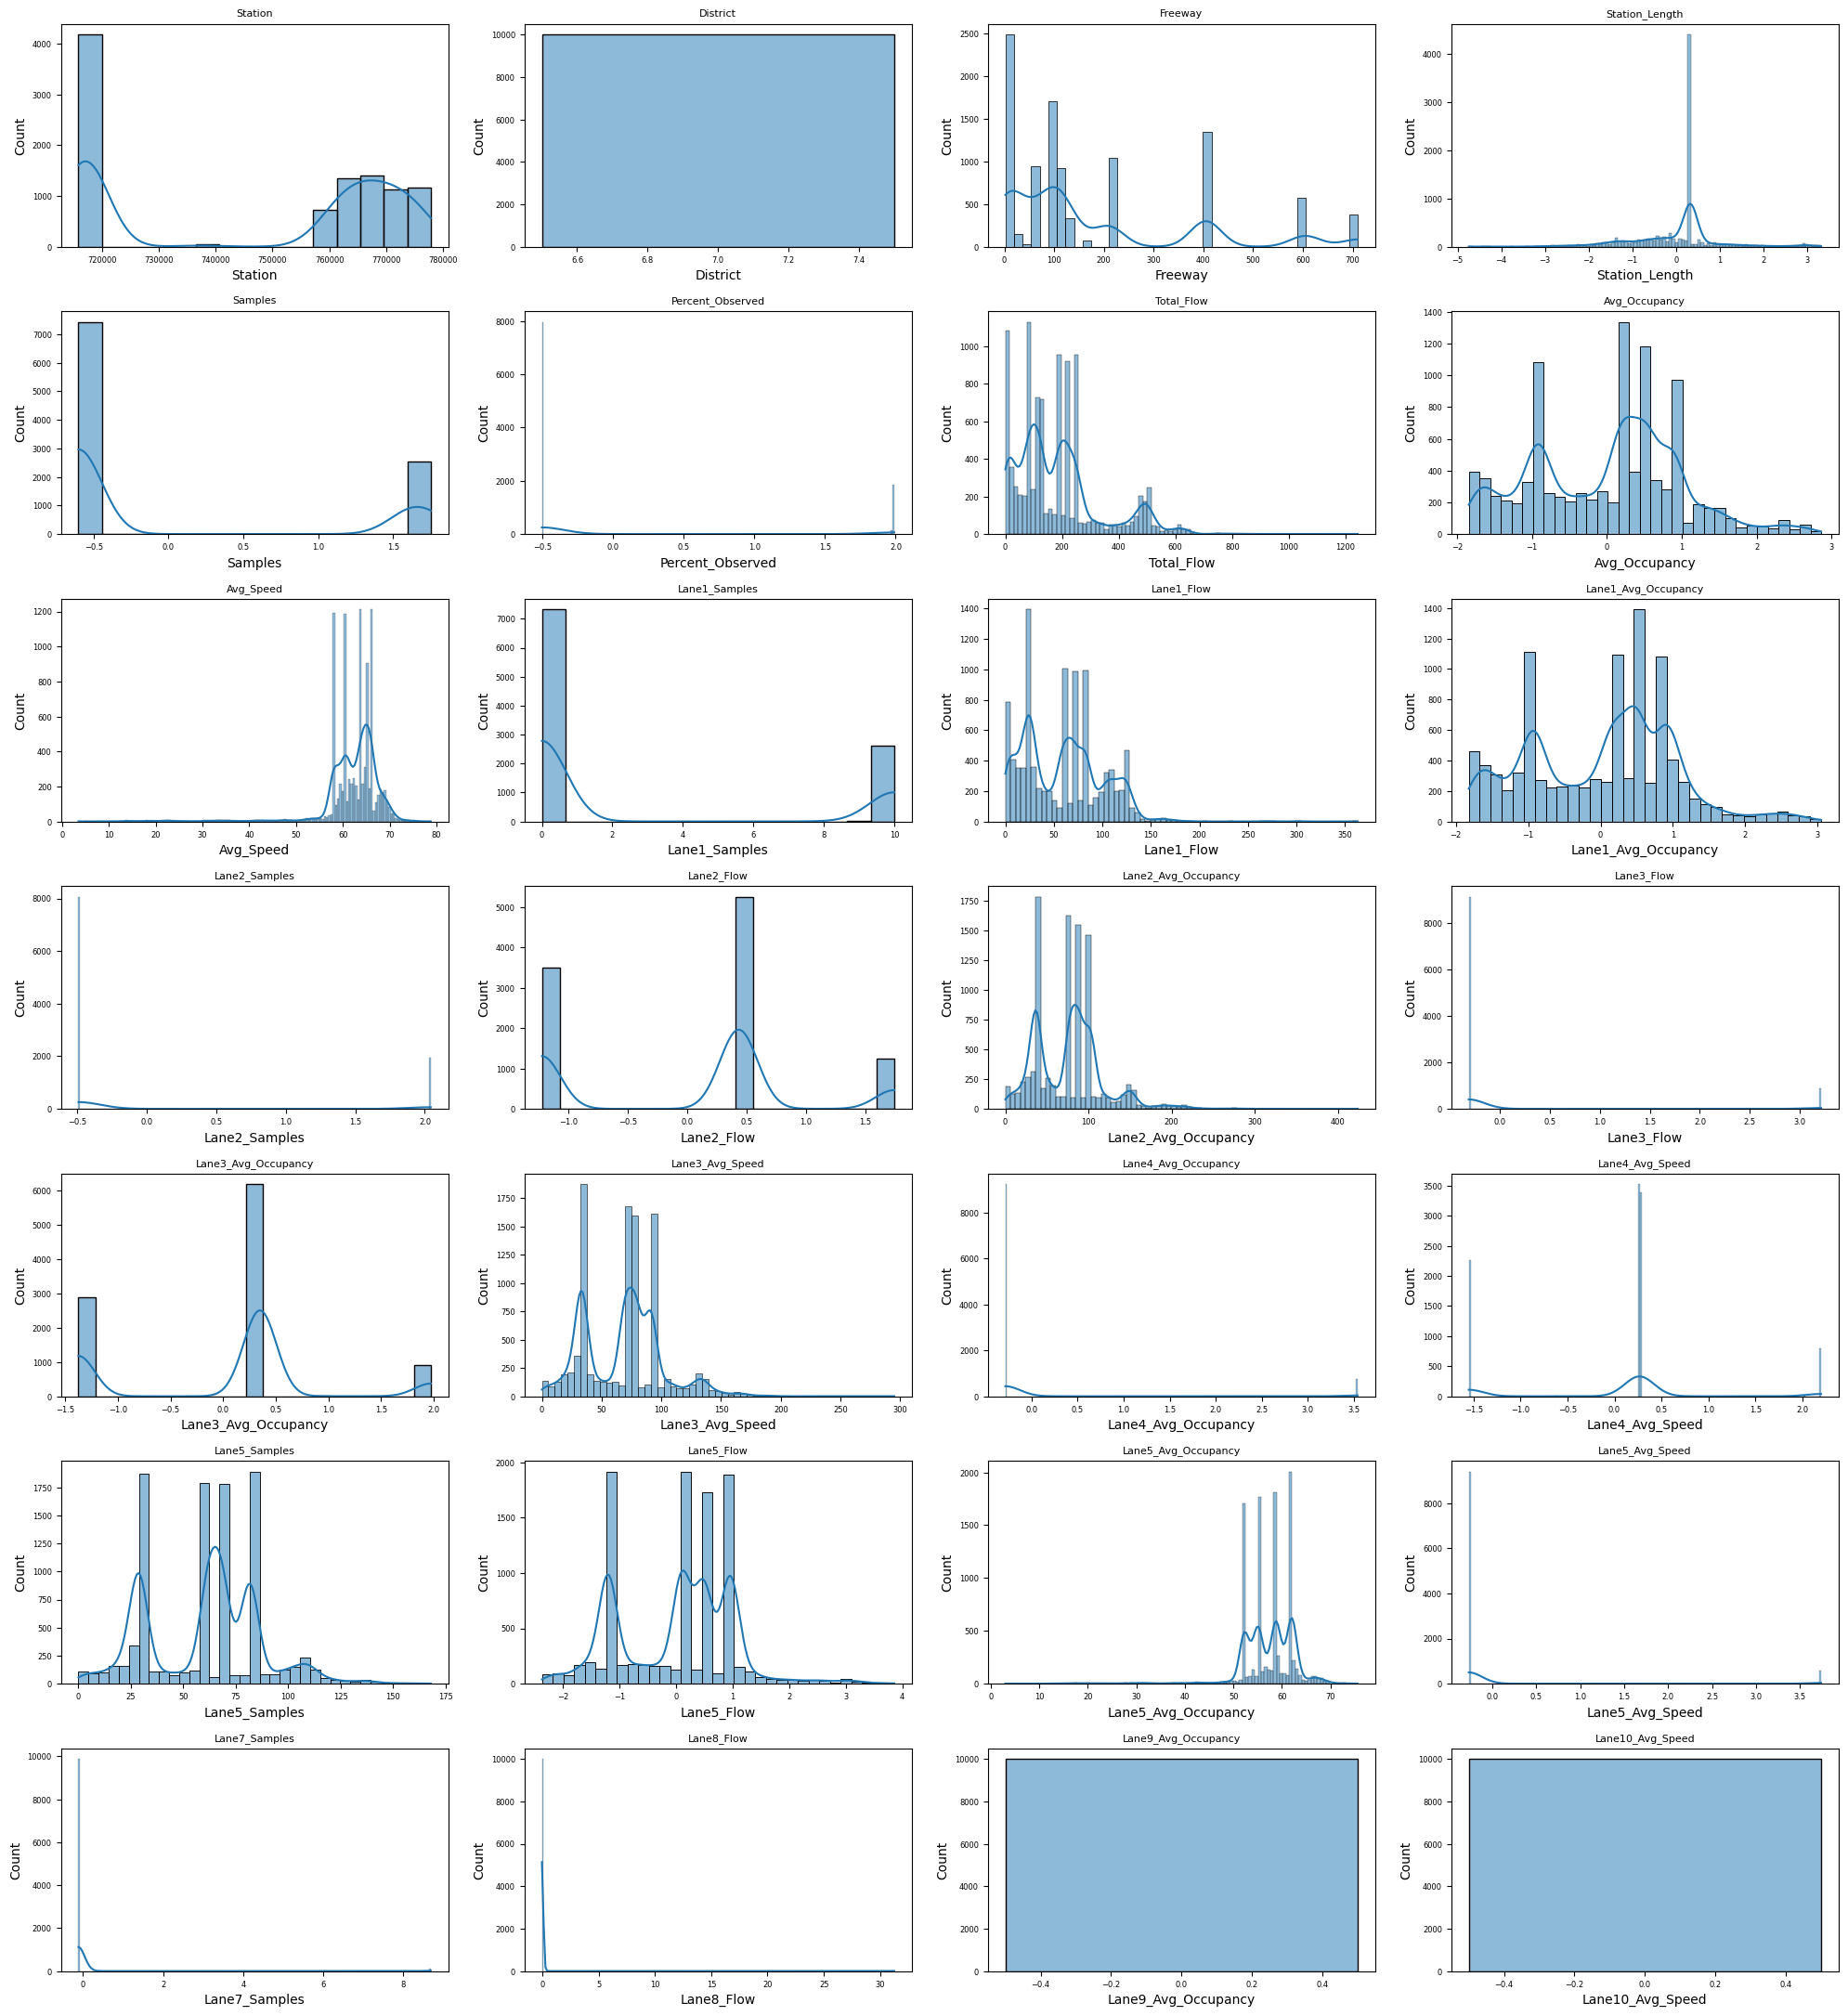

In [123]:
plt.figure(figsize=(20, 40))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(13, 4, i)

    # Downsample for performance
    sns.histplot(df[col].dropna().sample(10000), kde=True)

    plt.title(col, fontsize=8)
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()

In [124]:
df[cat_col].shape

(1407743, 8)

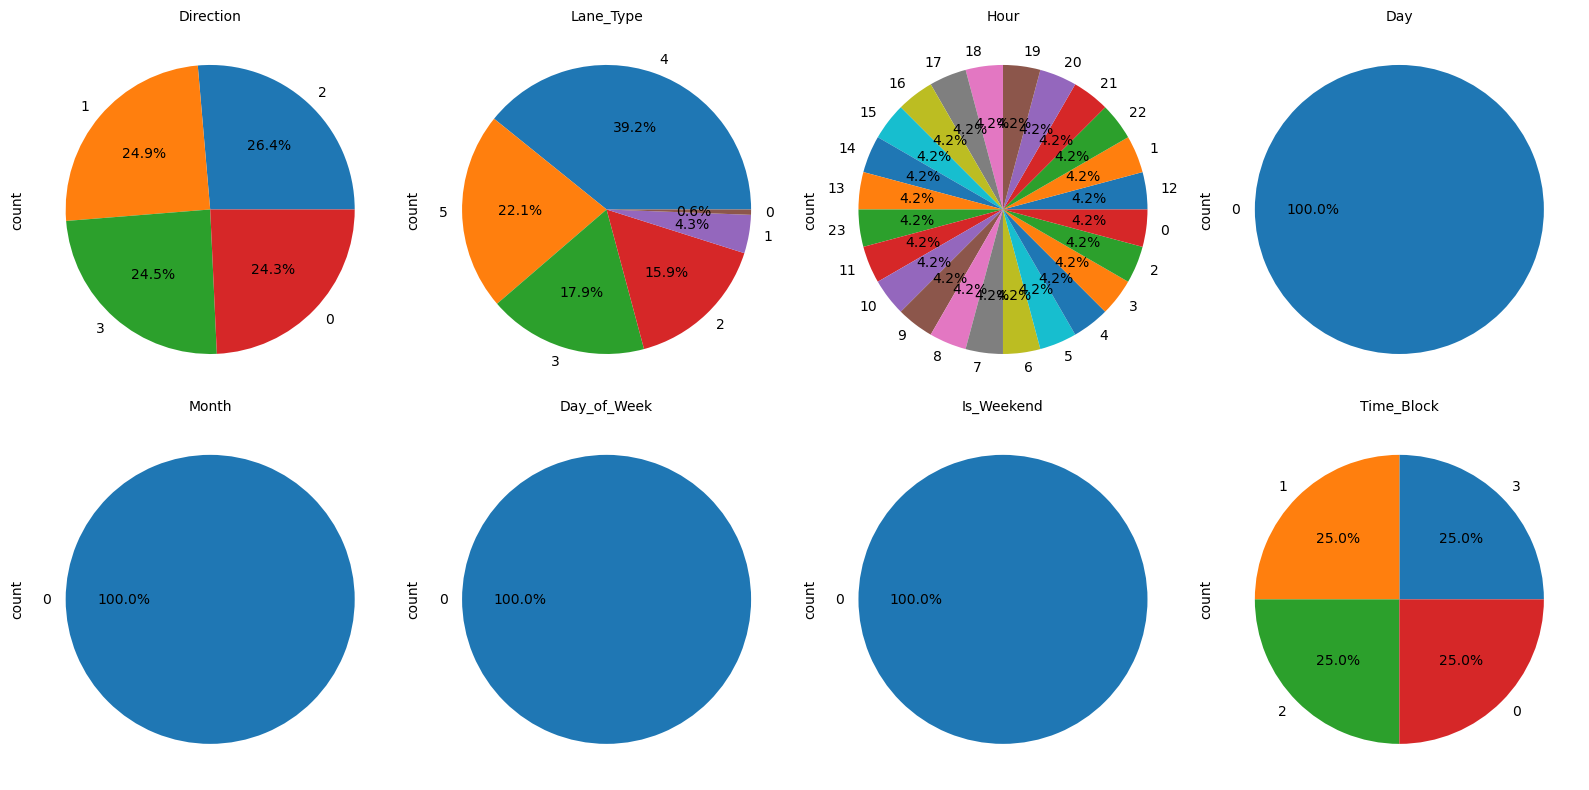

In [126]:
plt.figure(figsize=(16, 8))

for i, col in enumerate(cat_col, 1):
    plt.subplot(2, 4, i)
    df[col].value_counts().plot(kind='pie',autopct='%1.1f%%')
    plt.title(col, fontsize=10)
    plt.ylabel('count')
plt.tight_layout()
plt.show()

## Bivariate Analysis


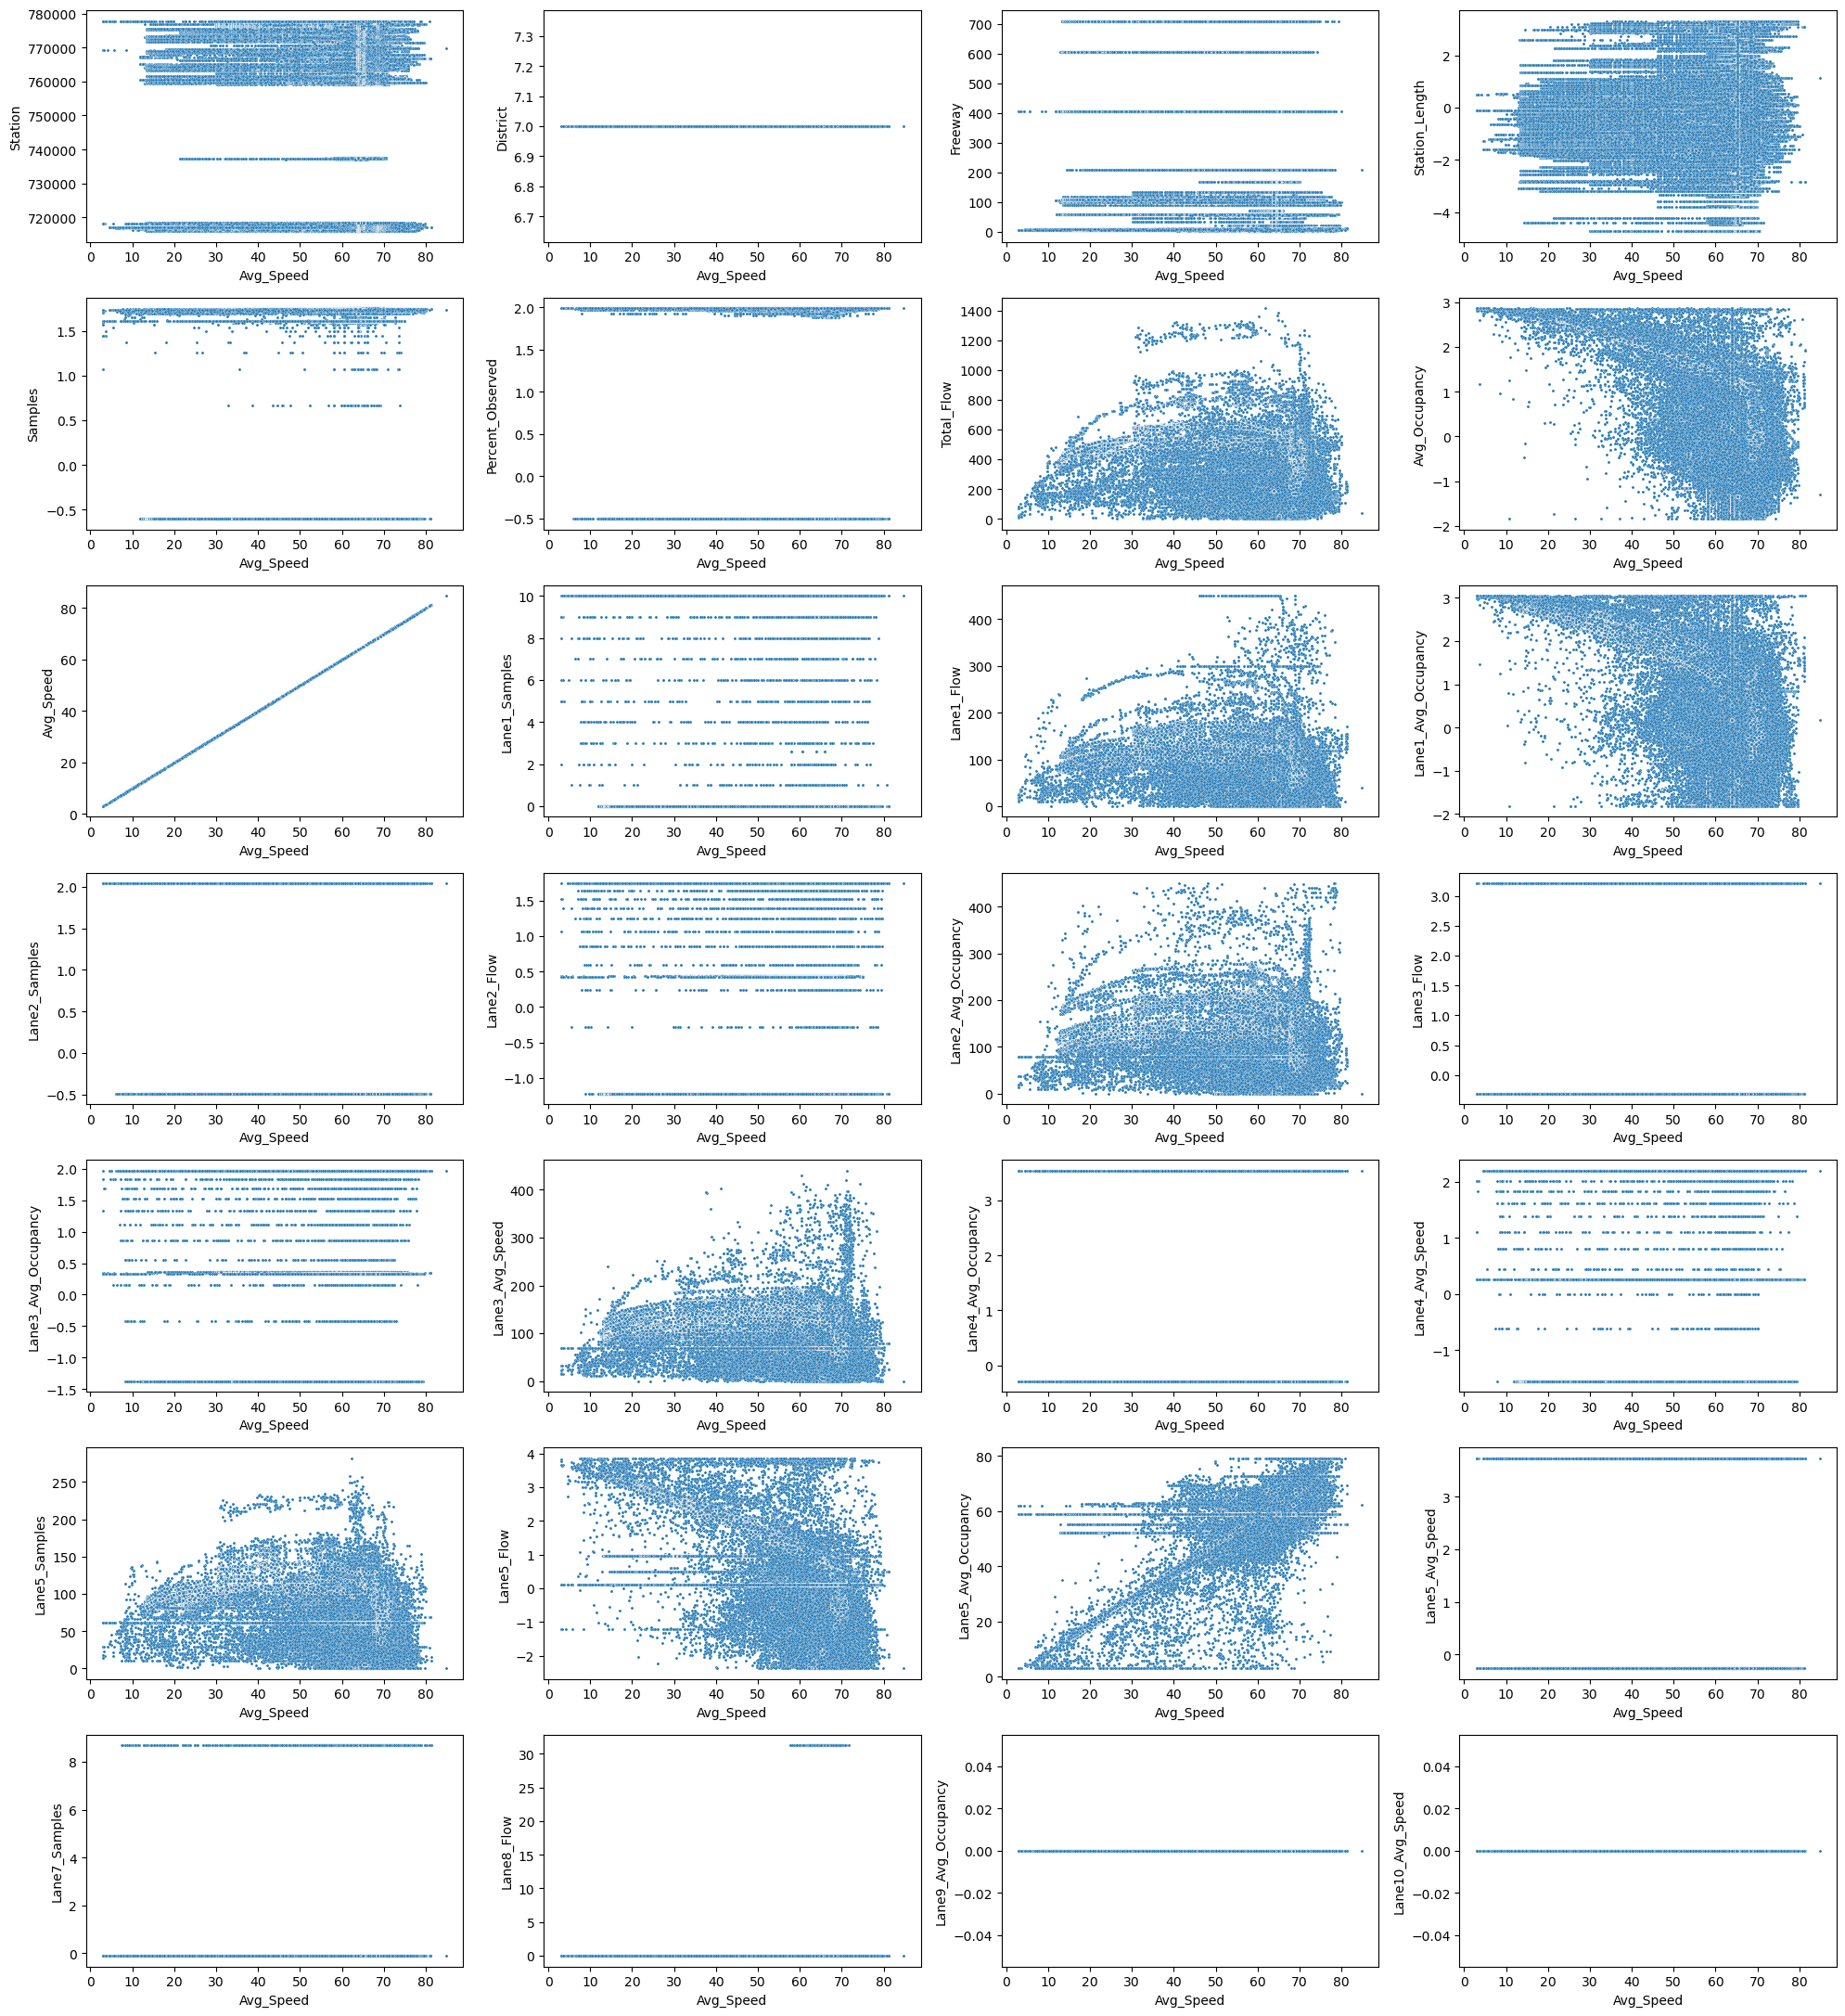

In [127]:
plt.figure(figsize=(20, 40))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(13, 4, i)
    sns.scatterplot(
        x=df['Avg_Speed'],
        y=df[col],
        s=5
    )

    plt.xlabel('Avg_Speed')
    plt.ylabel(f'{col}')

plt.tight_layout()
plt.show()

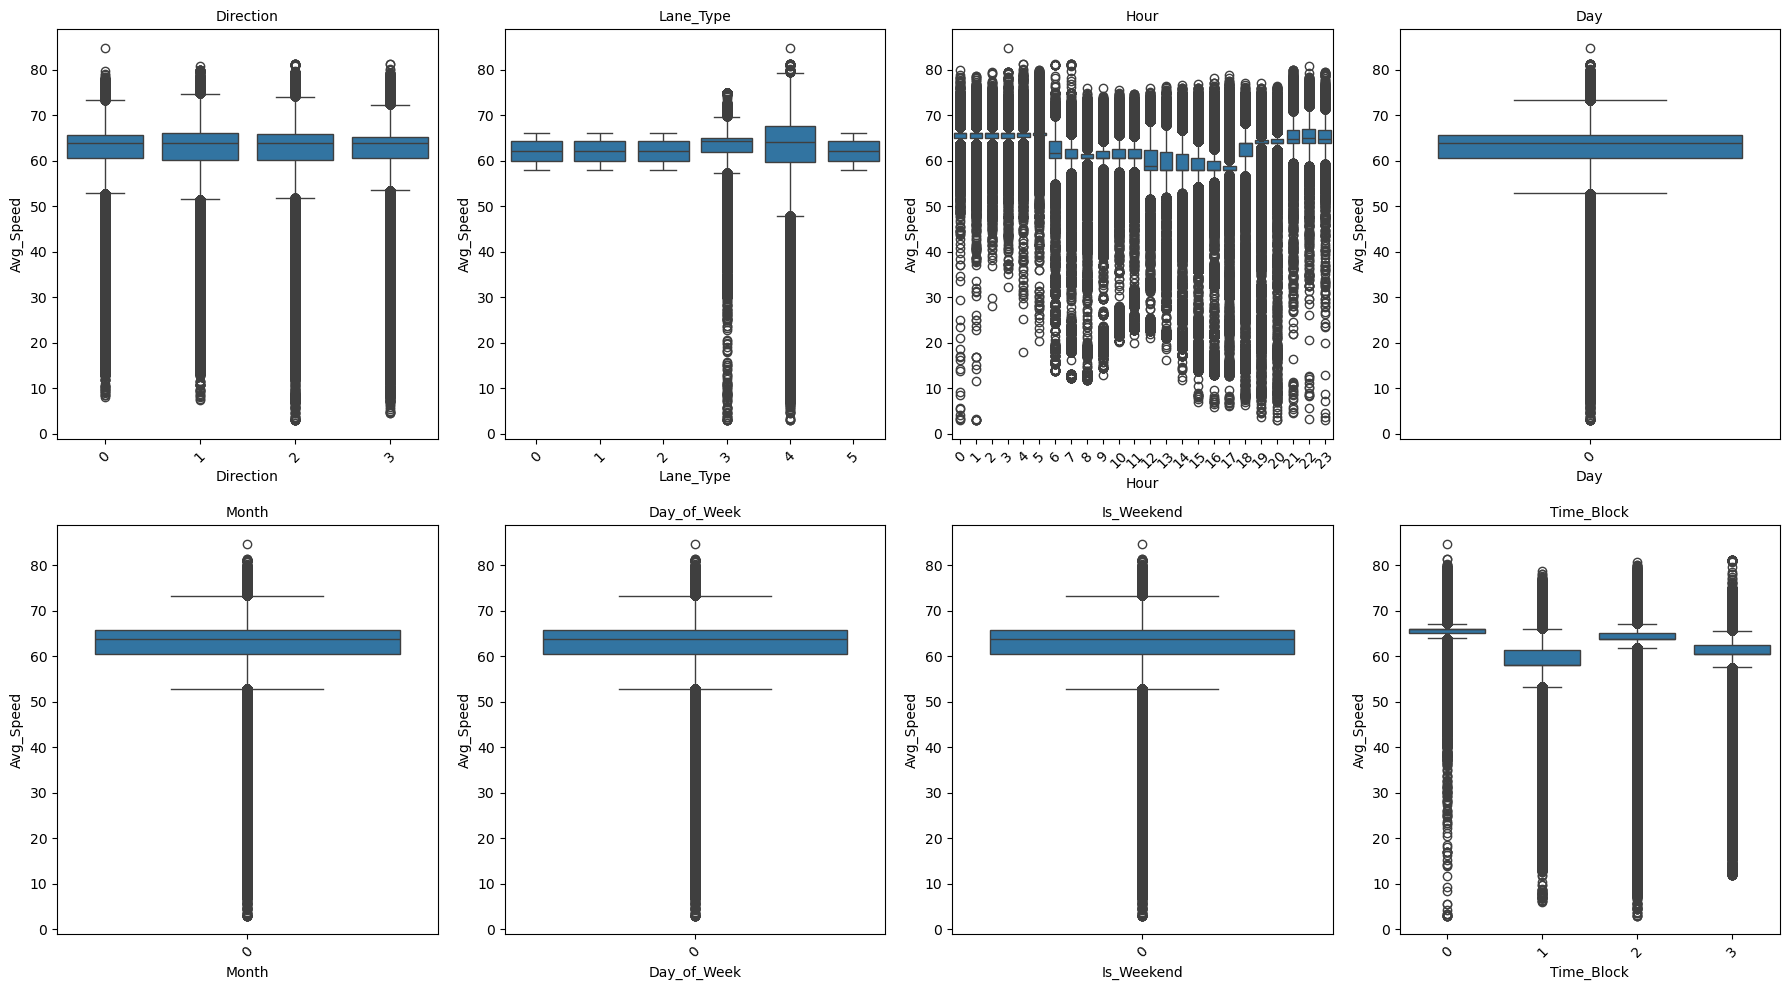

In [128]:
plt.figure(figsize=(18, 10))

for i, col in enumerate(cat_col, 1):
    plt.subplot(2, 4, i)

    sns.boxplot(
        x=df[col],
        y=df['Avg_Speed']
    )

    plt.title(col, fontsize=10)
    plt.xlabel(f'{col}')
    plt.ylabel('Avg_Speed')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Multivariate Analysis

<Axes: >

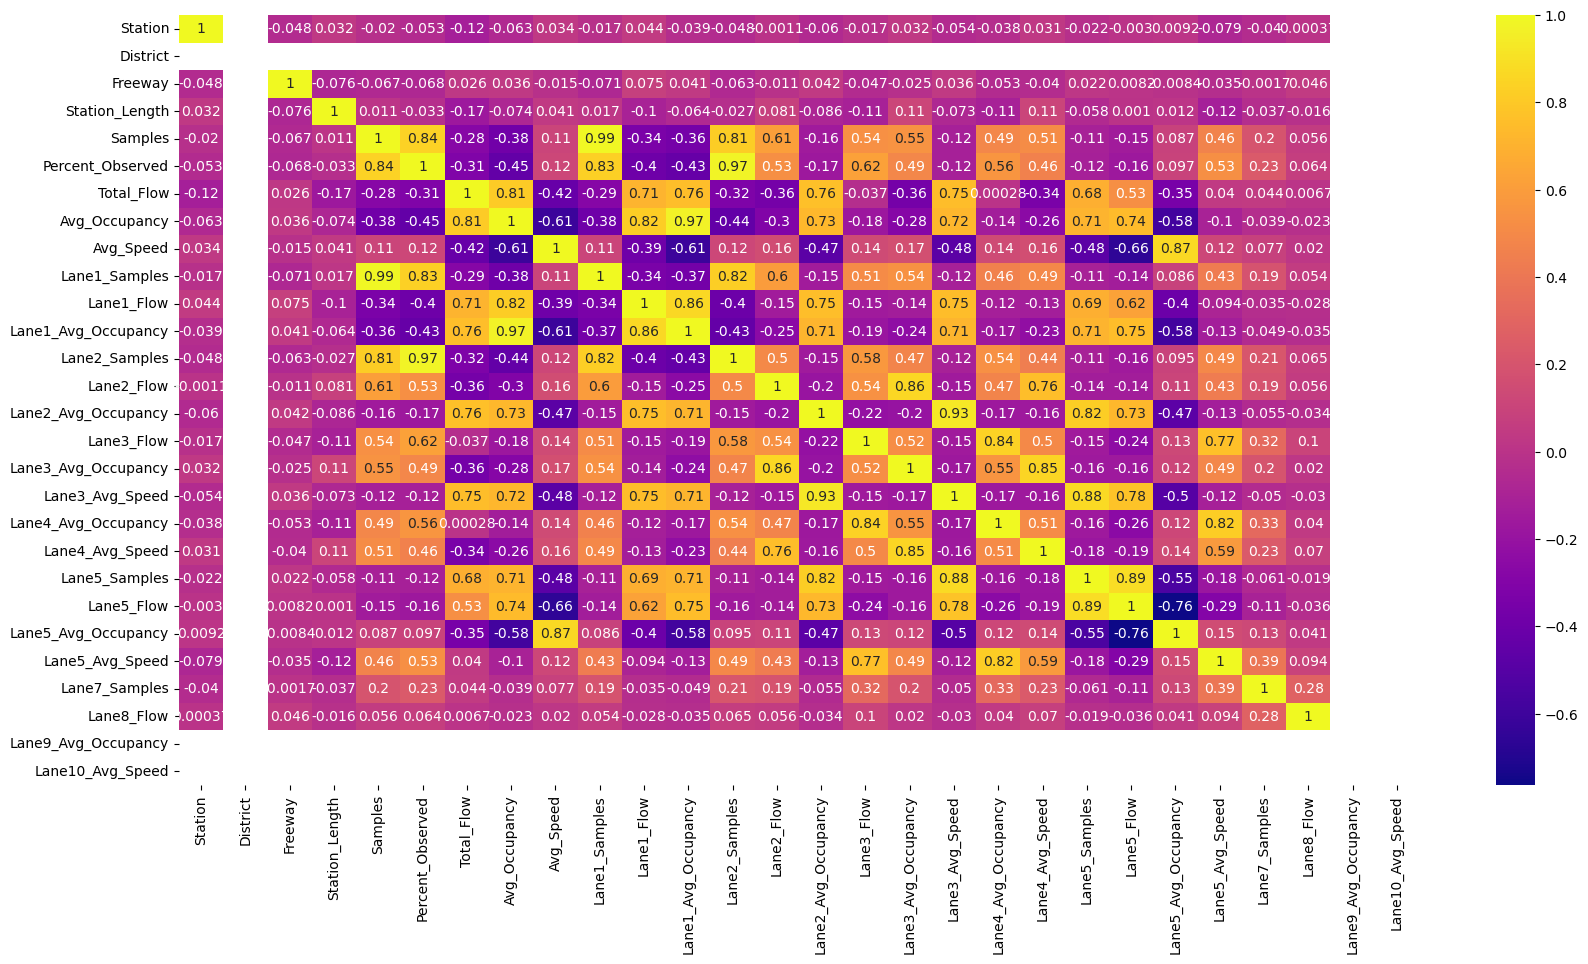

In [129]:
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='plasma')

In [30]:
corr_col = ['Lane1_Avg_Speed','Lane2_Avg_Speed','Lane3_Samples','Lane4_Samples','Lane4_Flow']

In [31]:
df = df.drop(columns = corr_col,axis=1)

In [32]:
numeric_cols = df.select_dtypes(include='number').columns.to_list()

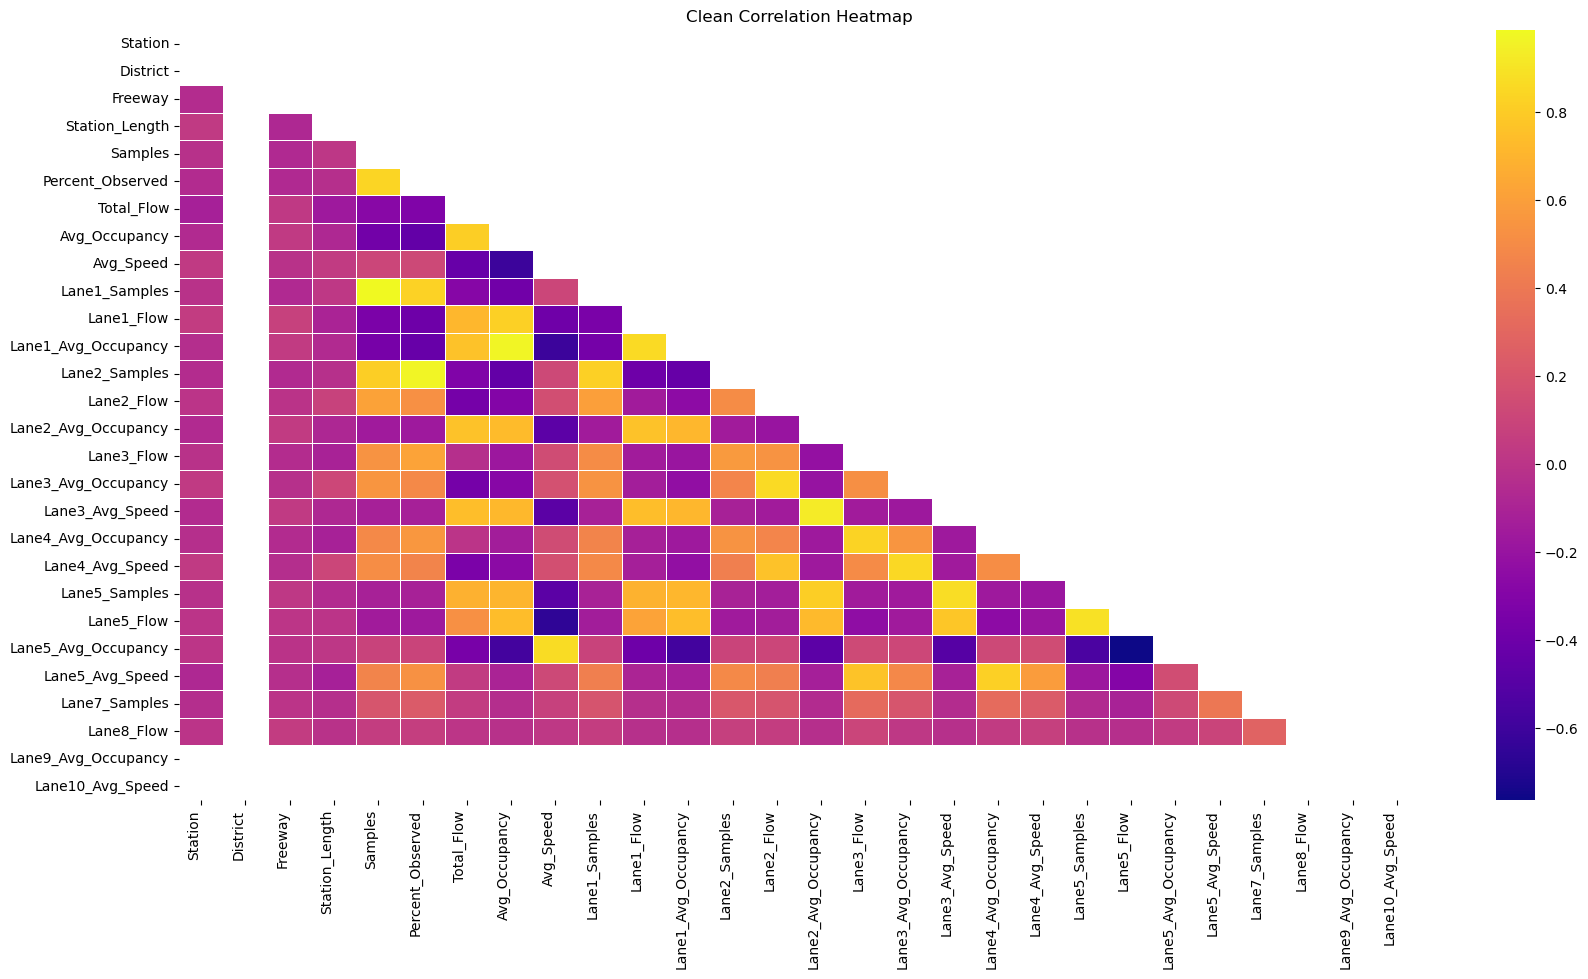

In [130]:
mask = np.triu(np.ones_like(df[numeric_cols].corr(), dtype=bool))

plt.figure(figsize=(20,10))
sns.heatmap(df[numeric_cols].corr(), mask=mask, cmap='plasma', linewidths=0.5)
plt.xticks(rotation=90, ha='right')
plt.title("Clean Correlation Heatmap")
plt.show()

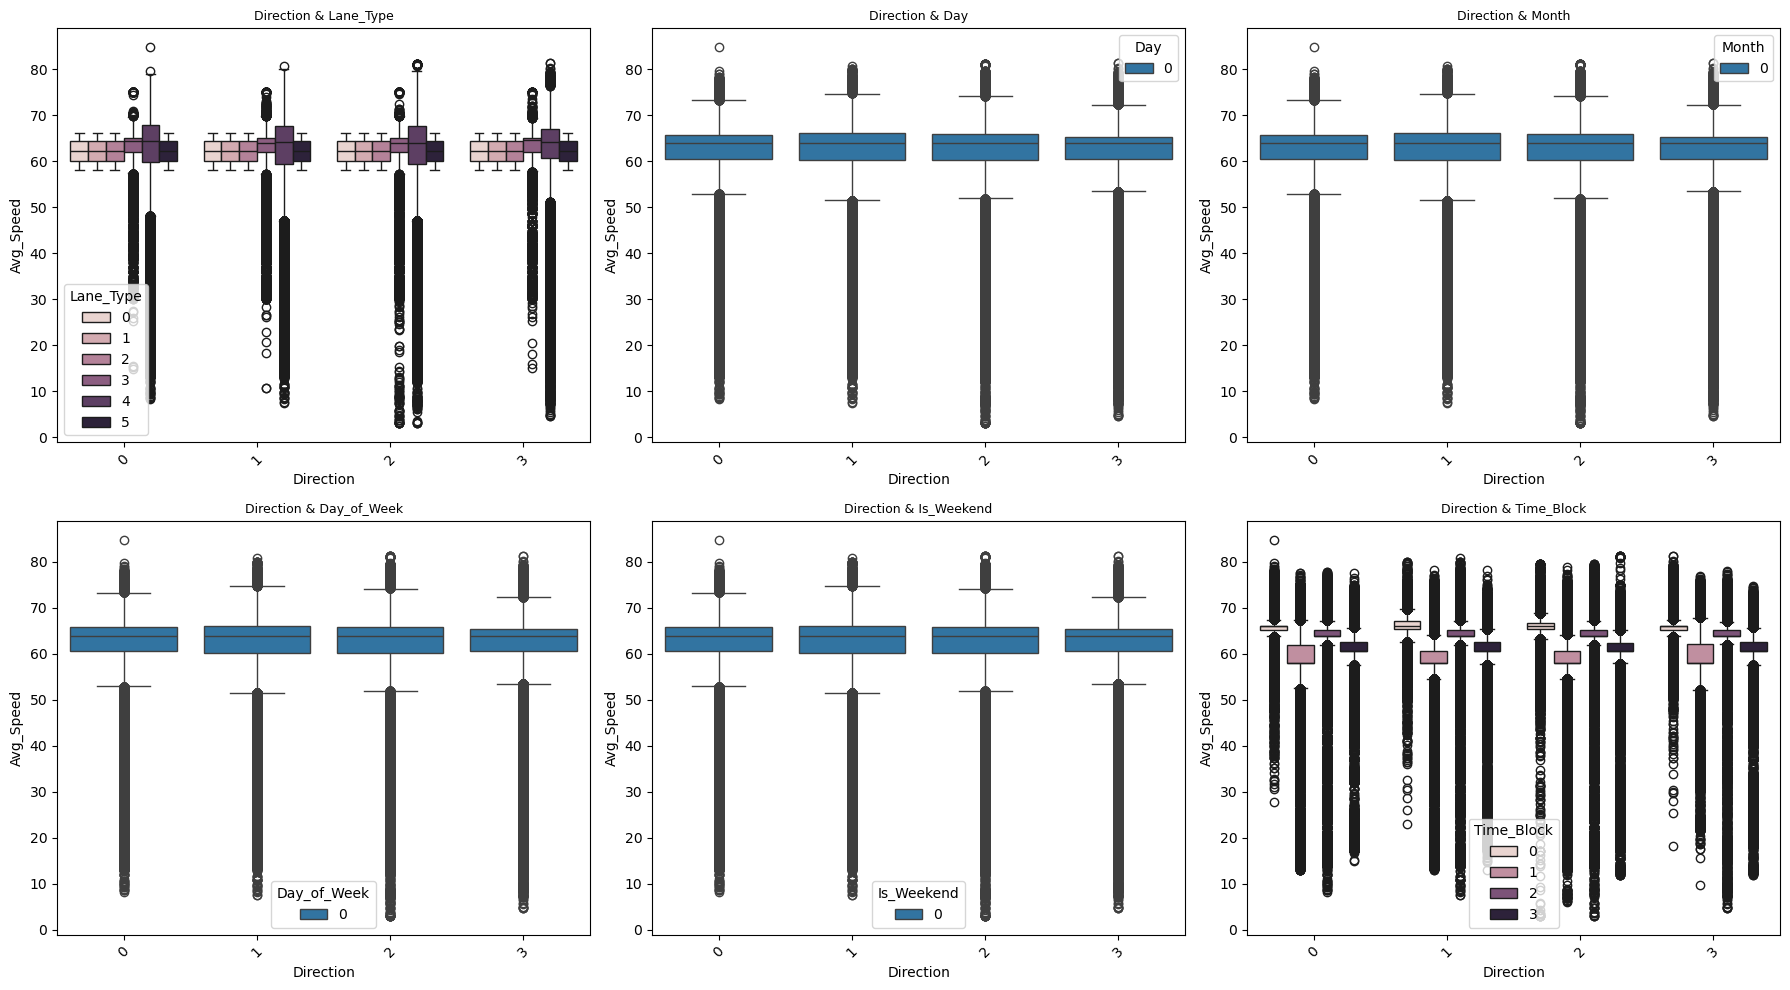

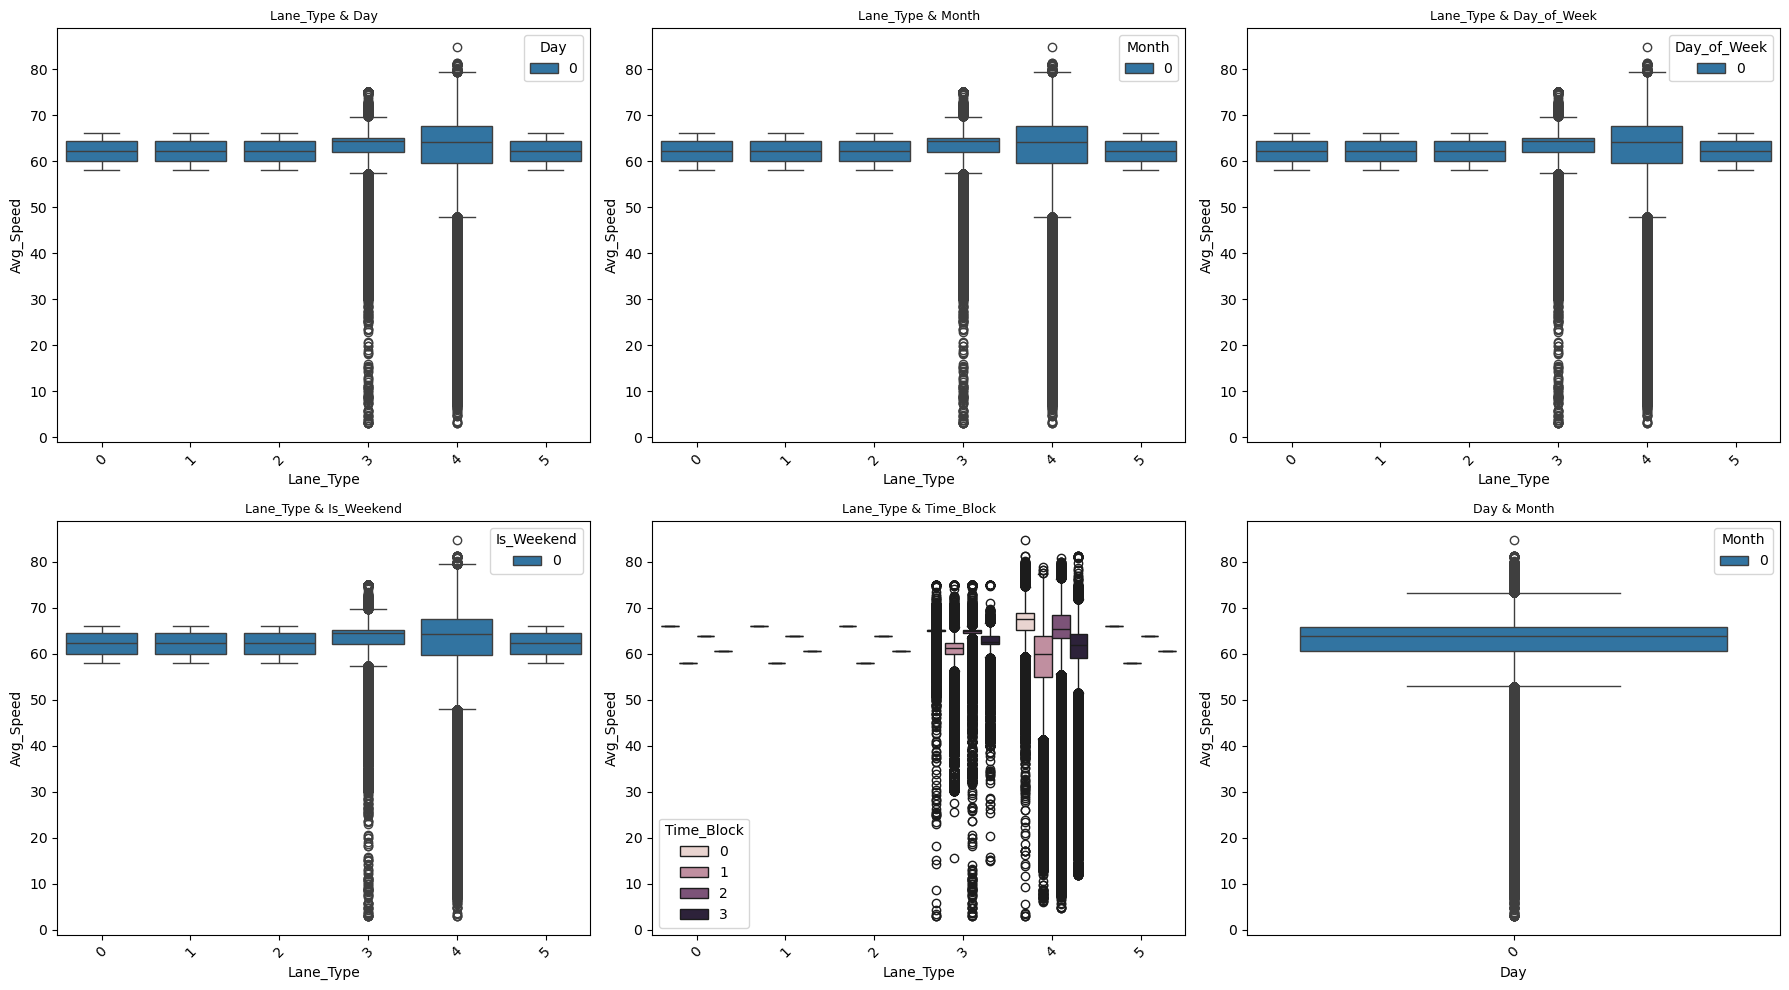

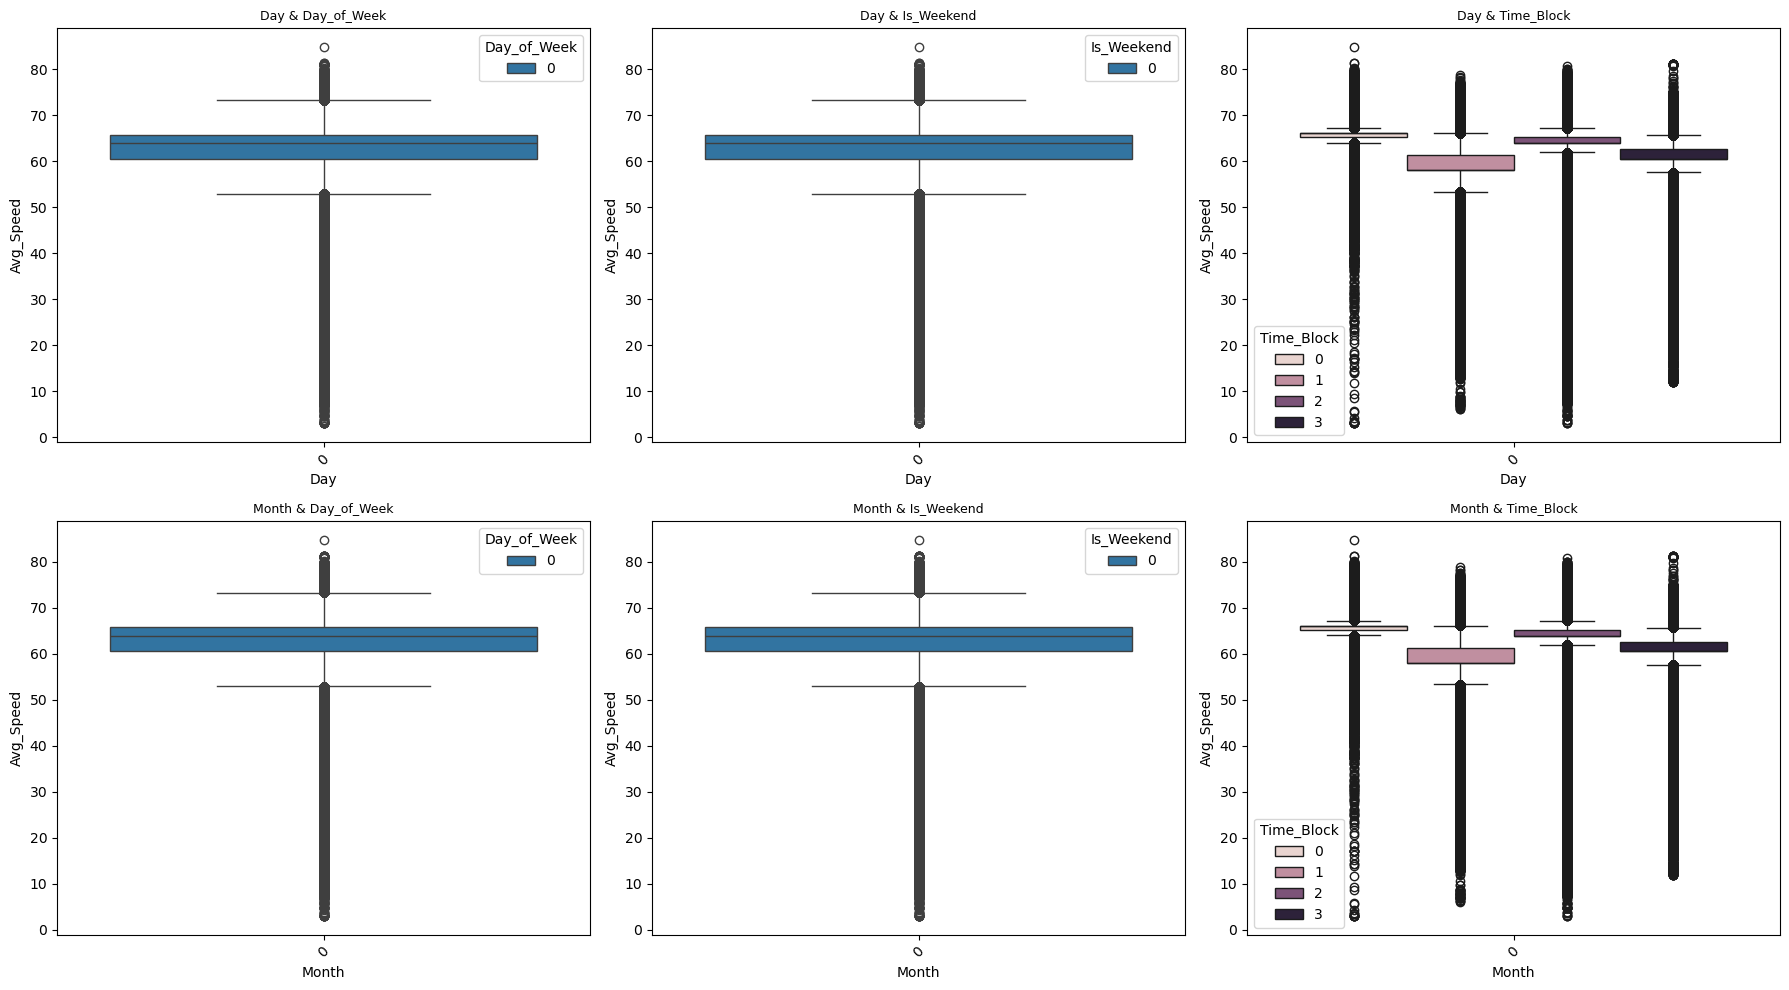

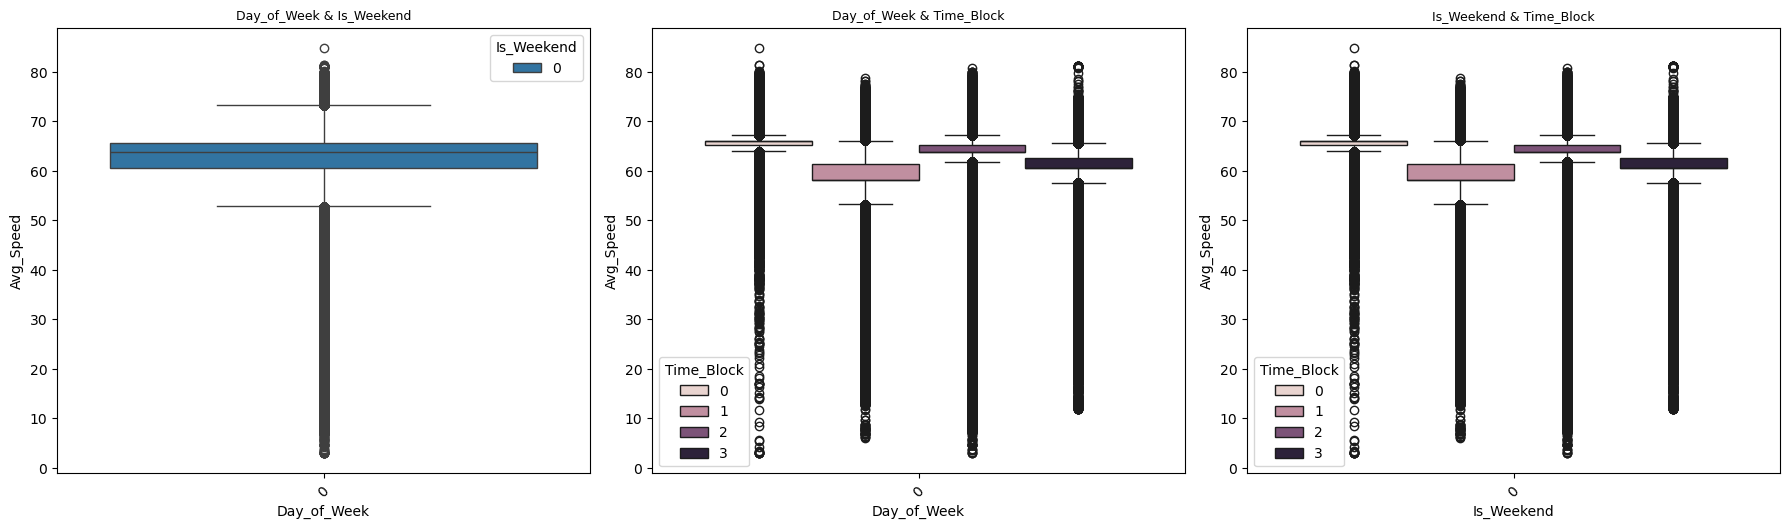

In [131]:
pairs = [
    (col1, col2)
    for col1, col2 in itertools.combinations(cat_col, 2)
    if df[col1].nunique() <= 10 and df[col2].nunique() <= 10
]

plots_per_page = 6
cols = 3
rows = 2

for page in range(0, len(pairs), plots_per_page):
    subset = pairs[page:page + plots_per_page]

    plt.figure(figsize=(18, 10))

    for i, (col1, col2) in enumerate(subset, 1):
        plt.subplot(rows, cols, i)



        sns.boxplot(
            x=df[col1],
            y=df['Avg_Speed'],
            hue=df[col2]
        )

        plt.title(f'{col1} & {col2}', fontsize=9)
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

## target related analysis

In [132]:
target = 'Avg_Speed'

## Top Correlated Features

In [133]:
corr = df.corr(numeric_only=True)[target].abs().sort_values(ascending=False)

top_features = corr[1:10].index
print(top_features)

Index(['Lane5_Avg_Occupancy', 'Lane5_Flow', 'Lane1_Avg_Occupancy',
       'Avg_Occupancy', 'Lane3_Avg_Speed', 'Lane5_Samples',
       'Lane2_Avg_Occupancy', 'Total_Flow', 'Lane1_Flow'],
      dtype='object')


there are total of 9 columns in the top features

## Univariate (ONLY important features)

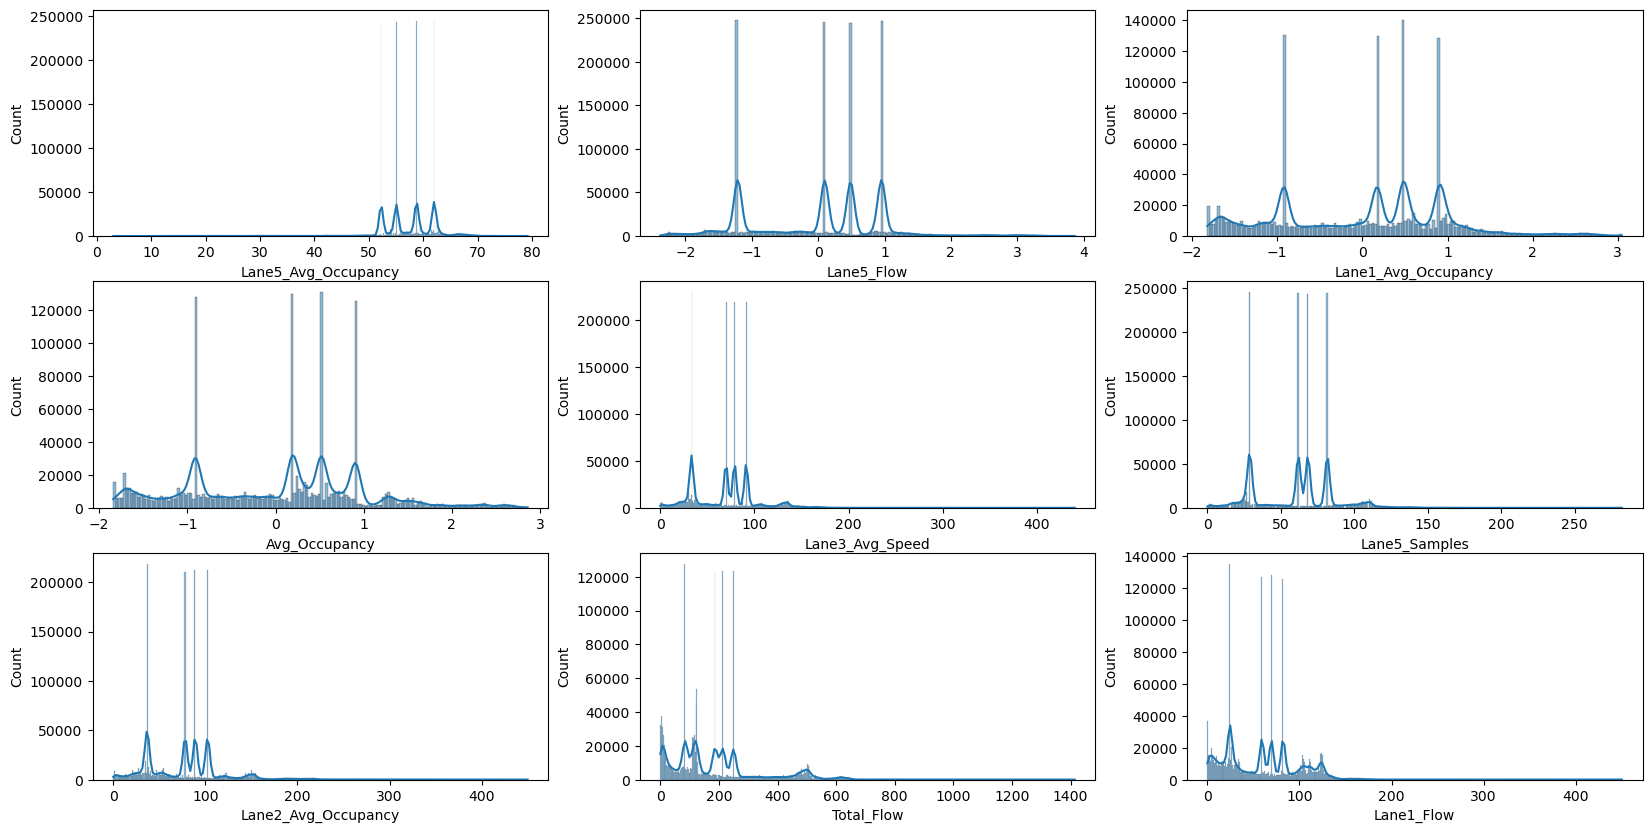

In [134]:
t=1
for col in top_features:
    plt.subplot(3, 3, t)
    sns.histplot(df[col], kde=True)
    t+=1

plt.show()

The loop visualizes the distribution of the most important numerical features, helping understand their data patterns, spread, skewness, and potential impact on the target variable.

## Categorical vs Target

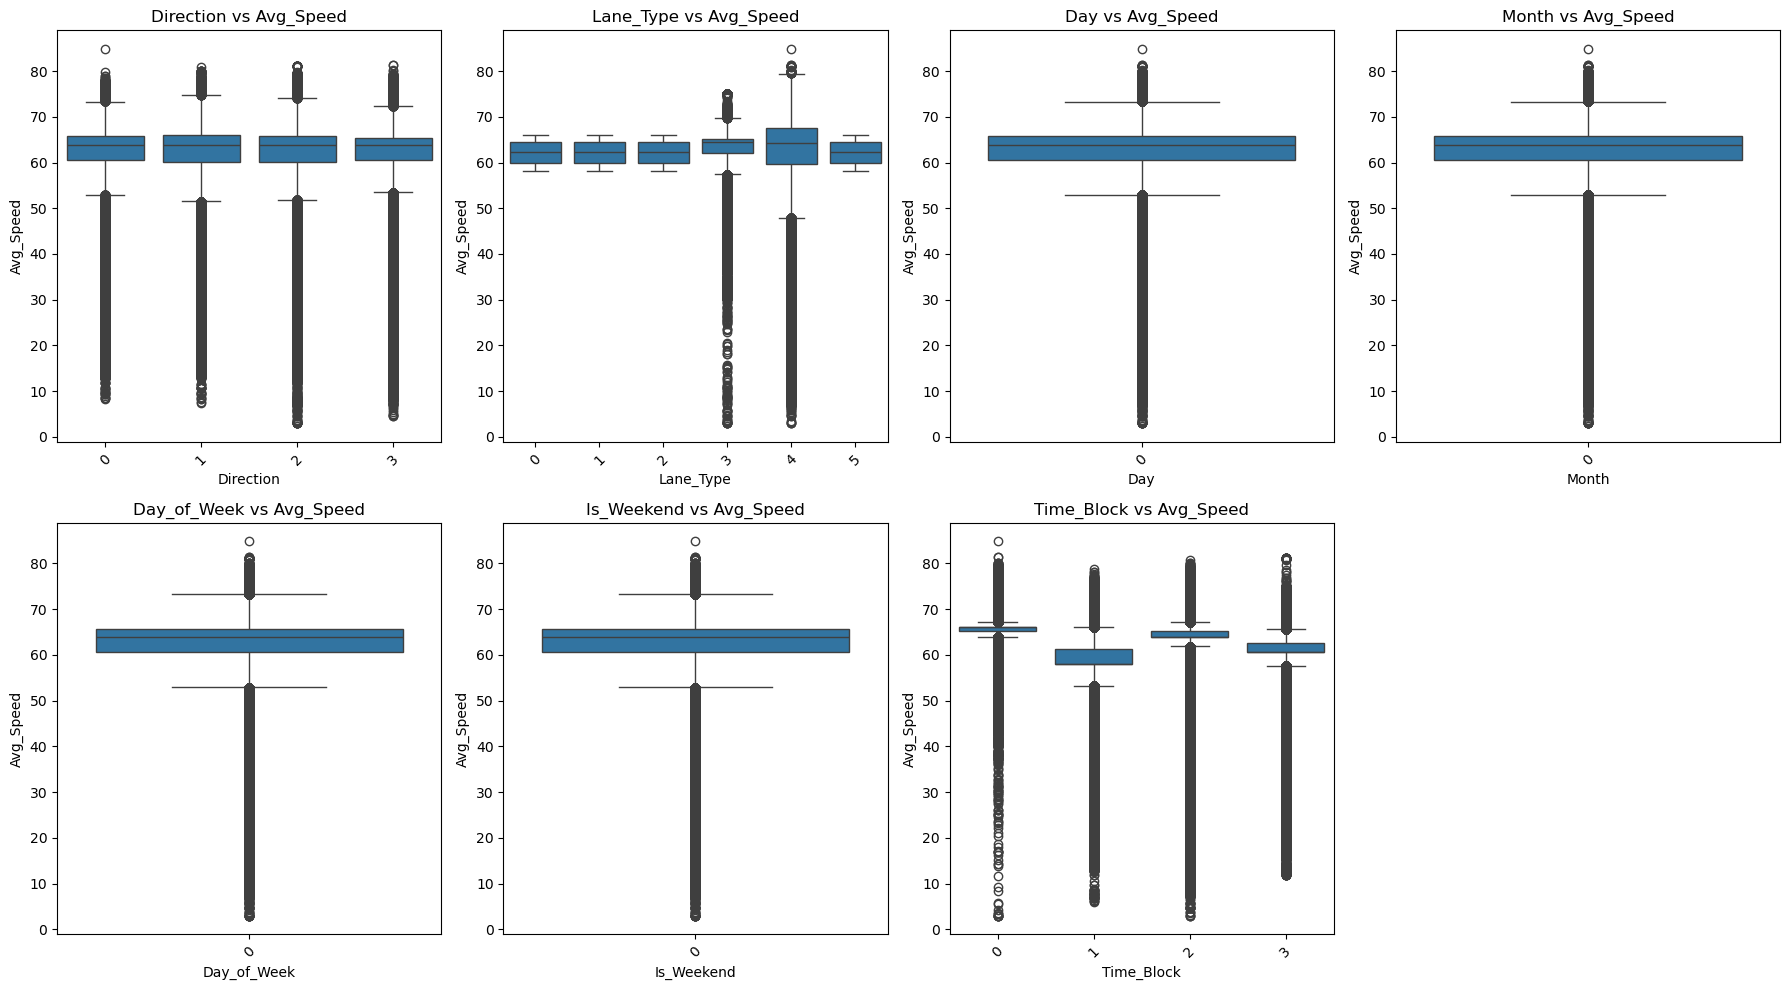

In [135]:
plt.figure(figsize=(18, 10))

t = 1
for col in cat_col:
    if df[col].nunique() > 10:
        continue

    plt.subplot(2, 4, t)

    sns.boxplot(x=df[col], y=df[target])
    plt.title(f'{col} vs {target}')
    plt.xticks(rotation=45)

    t += 1

plt.tight_layout()
plt.show()

The loop analyzes how the target variable varies across different categorical features, helping identify significant group differences, patterns, and the impact of categories on the target while avoiding clutter from high-cardinality variables.

## Clean Correlation Heatmap

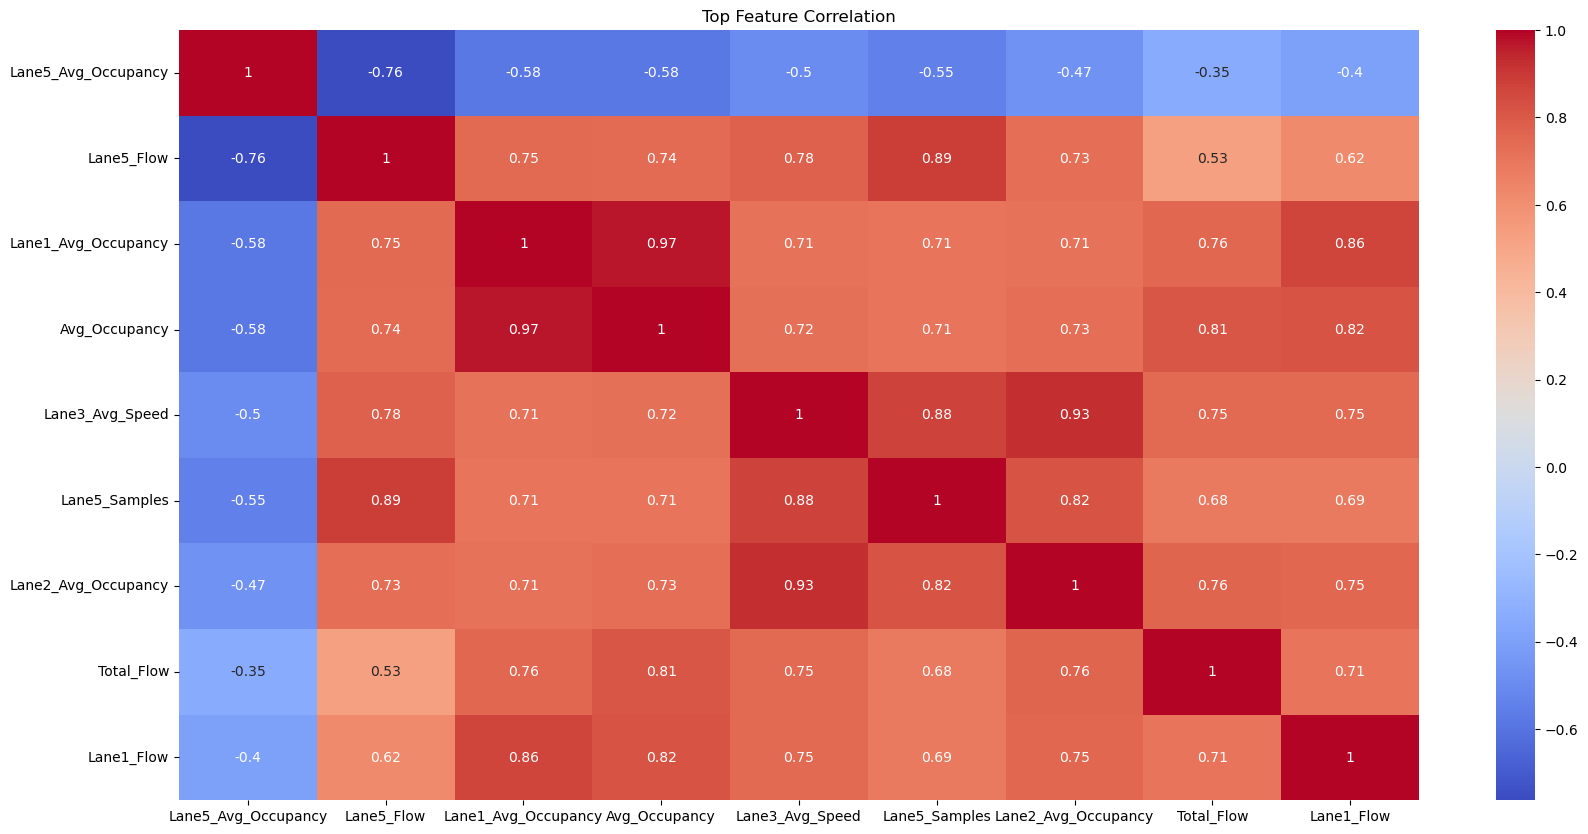

In [136]:
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm')
plt.title('Top Feature Correlation')
plt.show()

The heatmap highlights correlations among the most important features, helping identify strong relationships, dependencies, and potential multicollinearity within the key variables.

## Multivariate

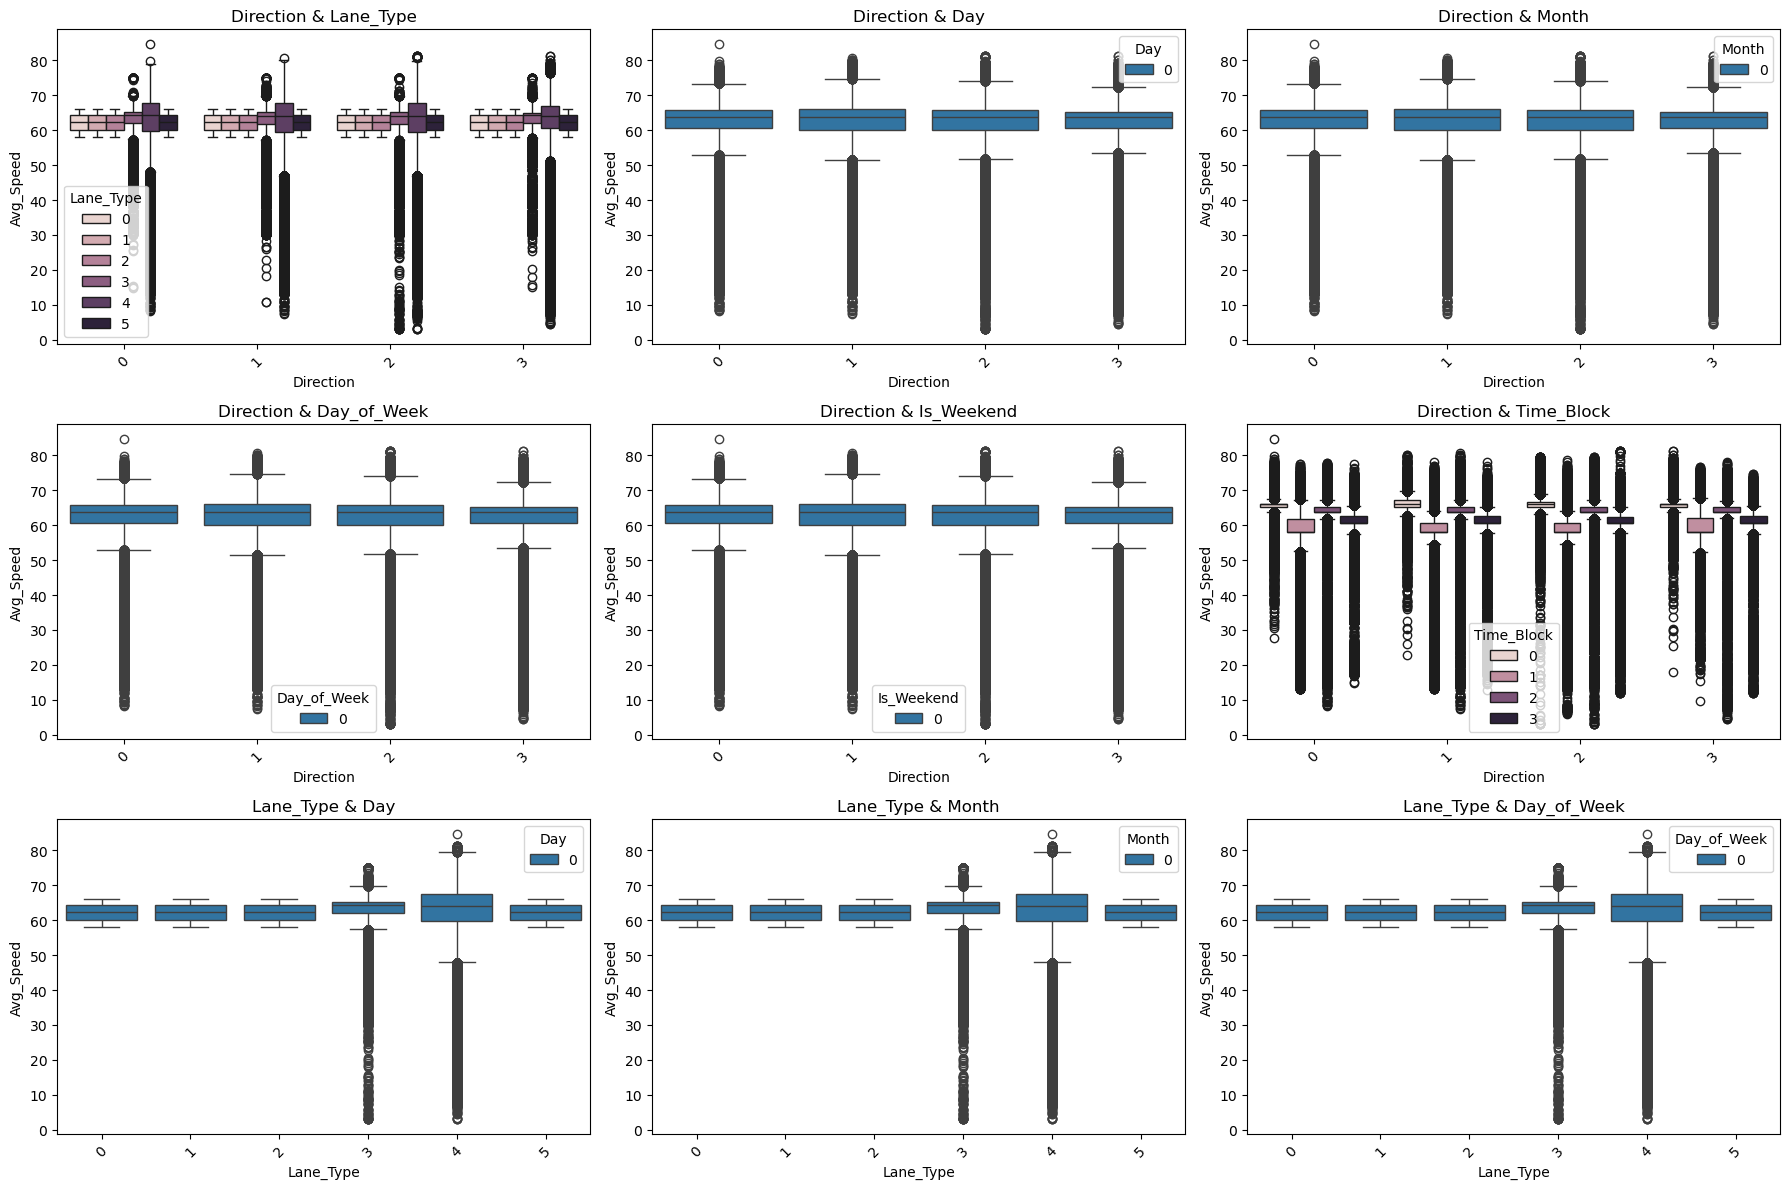

In [137]:
pairs = [
    (c1, c2) for c1, c2 in itertools.combinations(cat_col, 2)
    if df[c1].nunique() <= 8 and df[c2].nunique() <= 8
]

plt.figure(figsize=(18, 12))

for i, (col1, col2) in enumerate(pairs[:9], 1):
    plt.subplot(3, 3, i)

    sns.boxplot(x=df[col1], y=df[target], hue=df[col2])
    plt.title(f'{col1} & {col2}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The loop performs multivariate analysis by examining how the target variable varies across combinations of two categorical features, helping uncover interaction effects, group-based patterns, and combined influence of categories on the target.

## FINAL INSIGHTS

## Statistical Test

In [35]:
from scipy import stats

### CHI SQUARE(test for independence)

Ho: lane Type is not dependent on direction (independent)
Ha:lane Type is  dependent on direction  (dependent)

In [36]:
f_obs = pd.crosstab(df['Lane_Type'], df['Direction'])
f_obs.T

Lane_Type,CD,FF,FR,HV,ML,OR
Direction,,,,,,
E,2016,15552,52416,68832,130752,72000
N,864,12960,59328,54144,142847,80352
S,2016,15264,57888,59040,148320,88704
W,3456,16704,54720,69408,129888,70272


In [37]:
chi_stats, p_value, dof , f_exp = stats.chi2_contingency(f_obs)

In [38]:
print('Chi stats:', chi_stats)
print('P value:', p_value)
print('Chi crit:', stats.chi2.isf(0.05, dof))

Chi stats: 8392.099049622188
P value: 0.0
Chi crit: 24.99579013972863


Conclusion:

* P value < sig value ->  reject Ho
* stats > crit ->  reject Ho
* lane Type is  dependent on direction  (dependent)

Ho: Direction is not dependent on Station (independent)
Ha: Direction is  dependent on Station  (dependent)

In [50]:
f_obs = pd.crosstab(df['Direction'], df['Station'])
f_obs

Station,715898,715900,715901,715903,715904,715905,715906,715907,715908,715910,715911,715912,715913,715915,715916,715918,715920,715923,715924,715925,715926,715927,715928,715929,715930,715932,715933,715935,715937,715938,...,777262,777263,777285,777292,777316,777317,777434,777435,777600,777733,777734,777735,777738,777741,777745,777747,777751,777754,777765,777766,777767,777781,777782,777783,777784,777794,777795,777796,777797,777829
Direction,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
E,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,288,0,0,0,0,0,0,0,0,0,0,0,0
N,287,0,288,288,0,288,0,0,0,288,0,288,0,288,0,288,0,0,288,0,288,288,0,0,288,0,288,0,0,288,...,288,0,0,0,288,0,288,0,0,0,288,0,0,0,288,0,0,0,288,0,0,288,288,0,0,0,288,288,0,0
S,0,288,0,0,288,0,288,288,288,0,288,0,288,0,288,0,288,288,0,288,0,0,288,288,0,288,0,288,288,0,...,0,288,288,0,0,288,0,288,288,288,0,288,0,288,0,0,0,0,0,288,288,0,0,288,288,288,0,0,288,0
W,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,288,0,0,0,0,0,0,0,0,288,0,0,288,288,0,0,0,0,0,0,0,0,0,0,0,0,288


In [51]:
chi_stats, p_value, dof , f_exp = stats.chi2_contingency(f_obs)

In [52]:
print('Chi stats:', chi_stats)
print('P value:', p_value)
print('Chi crit:', stats.chi2.isf(0.05, dof))

Chi stats: 4223229.0
P value: 0.0
Chi crit: 14943.791708529317


Conclusion:

* P value < sig value ->  reject Ho
* stats > crit ->  reject Ho
*  Direction is  dependent on Station (dependent)

###  PearsonR

In [61]:
stats.pearsonr(df['Avg_Speed'], df['Total_Flow'])

PearsonRResult(statistic=np.float64(-0.42268975620252747), pvalue=np.float64(0.0))

Conclusion:

* P value < sig value ->  reject Ho
* Total_Flow has significant relation with Avg_Speed 

### ANOVA 

In [54]:
df['Lane_Type'].unique()

array(['OR', 'FR', 'ML', 'HV', 'FF', 'CD'], dtype=object)

In [55]:
samp1 = df[df['Lane_Type'] =='OR']['Avg_Speed']
samp2 = df[df['Lane_Type'] =='FR']['Avg_Speed']
samp3 = df[df['Lane_Type'] =='ML']['Avg_Speed']
samp4 = df[df['Lane_Type'] =='HV']['Avg_Speed']
samp5 = df[df['Lane_Type'] =='FF']['Avg_Speed']
samp6 = df[df['Lane_Type'] =='CD']['Avg_Speed']

In [56]:
stats.f_oneway(samp1,samp2,samp3,samp4,samp5,samp6)

F_onewayResult(statistic=np.float64(1590.1537008410946), pvalue=np.float64(0.0))

In [57]:
k = 6
N = len(df['Avg_Speed'])
dfb = k-1
dfw = N-k

In [58]:
f_crit = stats.f.isf(0.05,dfb,dfw)
f_crit

np.float64(2.2141058850892916)

CONCLUSION

* P value < sig value -> Reject Ho
* stats > crit -> Reject Ho

 Atleast mean of one group is different

In [59]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [60]:
pairwise_tukeyhsd(df['Avg_Speed'] , df['Lane_Type']).summary()

group1,group2,meandiff,p-adj,lower,upper,reject
CD,FF,-0.0,1.0,-0.2197,0.2197,False
CD,FR,0.0,1.0,-0.2097,0.2097,False
CD,HV,0.9732,0.0,0.7639,1.1825,True
CD,ML,-0.4434,0.0,-0.6509,-0.236,True
CD,OR,0.0,1.0,-0.2086,0.2086,False
FF,FR,0.0,1.0,-0.0862,0.0862,False
FF,HV,0.9732,0.0,0.888,1.0585,True
FF,ML,-0.4434,0.0,-0.524,-0.3629,True
FF,OR,0.0,1.0,-0.0836,0.0836,False
FR,HV,0.9732,0.0,0.9186,1.0279,True


* ML highest, HV second (both significantly different from most others)
* CD, FF, FR, OR → no significant differences among them
* Overall: CD ≈ FF ≈ FR ≈ OR < HV < ML

## Encoding

In [39]:
df[cat_col].columns

Index(['Direction', 'Lane_Type', 'Hour', 'Day', 'Month', 'Day_of_Week',
       'Is_Weekend', 'Time_Block'],
      dtype='object')

In [40]:
from sklearn.preprocessing import LabelEncoder

In [41]:
label_en = ['Direction', 'Lane_Type', 'Hour', 'Day', 'Month', 'Day_of_Week',
       'Is_Weekend', 'Time_Block']

In [42]:
l = LabelEncoder()

In [43]:
for i in label_en:
    df[i] = l.fit_transform(df[[i]])

## Transformation

In [44]:
df[numeric_cols].skew()

Station                -0.260770
District                0.000000
Freeway                 1.283226
Station_Length          5.368983
Samples                 2.285479
Percent_Observed        1.572751
Total_Flow              1.223535
Avg_Occupancy           3.592166
Avg_Speed              -3.593708
Lane1_Samples           1.091425
Lane1_Flow              0.618477
Lane1_Avg_Occupancy     5.168561
Lane2_Samples           1.553642
Lane2_Flow              1.643955
Lane2_Avg_Occupancy     0.935474
Lane3_Flow              2.901347
Lane3_Avg_Occupancy     1.886591
Lane3_Avg_Speed         0.560700
Lane4_Avg_Occupancy     3.256620
Lane4_Avg_Speed         1.970807
Lane5_Samples           0.128048
Lane5_Flow              3.249612
Lane5_Avg_Occupancy    -2.730799
Lane5_Avg_Speed         3.472902
Lane7_Samples           8.567427
Lane8_Flow             31.218623
Lane9_Avg_Occupancy     0.000000
Lane10_Avg_Speed        0.000000
dtype: float64

In [45]:
skew_col = []
for i in numeric_cols:
    if df[i].skew() > 1.5:
        skew_col.append(i)
skew_col

['Station_Length',
 'Samples',
 'Percent_Observed',
 'Avg_Occupancy',
 'Lane1_Avg_Occupancy',
 'Lane2_Samples',
 'Lane2_Flow',
 'Lane3_Flow',
 'Lane3_Avg_Occupancy',
 'Lane4_Avg_Occupancy',
 'Lane4_Avg_Speed',
 'Lane5_Flow',
 'Lane5_Avg_Speed',
 'Lane7_Samples',
 'Lane8_Flow']

In [46]:
skew_col

['Station_Length',
 'Samples',
 'Percent_Observed',
 'Avg_Occupancy',
 'Lane1_Avg_Occupancy',
 'Lane2_Samples',
 'Lane2_Flow',
 'Lane3_Flow',
 'Lane3_Avg_Occupancy',
 'Lane4_Avg_Occupancy',
 'Lane4_Avg_Speed',
 'Lane5_Flow',
 'Lane5_Avg_Speed',
 'Lane7_Samples',
 'Lane8_Flow']

In [47]:
from sklearn.preprocessing import PowerTransformer

In [48]:
p = PowerTransformer()

In [49]:
for i in skew_col:
    df[i] = p.fit_transform(df[[i]])

In [50]:
df

,Station,District,Freeway,Direction,Lane_Type,Station_Length,Samples,Percent_Observed,Total_Flow,Avg_Occupancy,Avg_Speed,Lane1_Samples,Lane1_Flow,Lane1_Avg_Occupancy,Lane2_Samples,Lane2_Flow,Lane2_Avg_Occupancy,Lane3_Flow,Lane3_Avg_Occupancy,Lane3_Avg_Speed,Lane4_Avg_Occupancy,Lane4_Avg_Speed,Lane5_Samples,Lane5_Flow,Lane5_Avg_Occupancy,Lane5_Avg_Speed,Lane7_Samples,Lane8_Flow,Lane9_Avg_Occupancy,Lane10_Avg_Speed,Hour,Day,Month,Day_of_Week,Is_Weekend,Time_Block
0,715900,7,5,2,5,0.333122,-0.601256,-0.503195,84.724540,-0.908987,66.022885,0.0,24.538604,-0.921468,-0.489454,0.436289,36.845442,-0.311273,0.349541,33.203432,-0.282552,0.267212,28.894406,-1.209573,61.987919,-0.267361,-0.115173,-0.031999,0,0,0,0,0,0,0,0
1,715901,7,5,1,5,0.333122,-0.601256,-0.503195,84.724540,-0.908987,66.022885,0.0,24.538604,-0.921468,-0.489454,0.436289,36.845442,-0.311273,0.349541,33.203432,-0.282552,0.267212,28.894406,-1.209573,61.987919,-0.267361,-0.115173,-0.031999,0,0,0,0,0,0,0,0
2,715903,7,5,1,5,0.333122,-0.601256,-0.503195,84.724540,-0.908987,66.022885,0.0,24.538604,-0.921468,-0.489454,0.436289,36.845442,-0.311273,0.349541,33.203432,-0.282552,0.267212,28.894406,-1.209573,61.987919,-0.267361,-0.115173,-0.031999,0,0,0,0,0,0,0,0
3,715904,7,5,2,5,0.333122,-0.601256,-0.503195,84.724540,-0.908987,66.022885,0.0,24.538604,-0.921468,-0.489454,0.436289,36.845442,-0.311273,0.349541,33.203432,-0.282552,0.267212,28.894406,-1.209573,61.987919,-0.267361,-0.115173,-0.031999,0,0,0,0,0,0,0,0
4,715905,7,5,1,5,0.333122,-0.601256,-0.503195,84.724540,-0.908987,66.022885,0.0,24.538604,-0.921468,-0.489454,0.436289,36.845442,-0.311273,0.349541,33.203432,-0.282552,0.267212,28.894406,-1.209573,61.987919,-0.267361,-0.115173,-0.031999,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407738,777794,7,5,2,3,2.944390,1.606018,-0.503195,115.000000,2.771673,23.600000,10.0,115.000000,2.983507,-0.489454,0.424989,78.066196,-0.311273,0.334730,69.729837,-0.282552,0.259010,61.934007,0.099499,58.760475,-0.267361,-0.115173,-0.031999,0,0,23,0,0,0,0,2
1407739,777795,7,5,1,3,2.944390,1.606018,1.989968,3.000000,-1.762707,65.000000,10.0,3.000000,-1.732082,2.043094,0.424989,78.066196,-0.311273,0.334730,69.729837,-0.282552,0.259010,61.934007,0.099499,58.760475,-0.267361,-0.115173,-0.031999,0,0,23,0,0,0,0,2
1407740,777796,7,5,1,4,-1.019743,1.736569,1.989968,76.000000,2.729461,57.500000,1.0,10.000000,3.044020,2.043094,1.742702,20.000000,3.212616,1.838037,20.000000,3.539169,2.200012,24.000000,-1.612013,79.200000,3.740260,8.682591,-0.031999,0,0,23,0,0,0,0,2
1407741,777797,7,5,2,2,0.333127,1.692870,1.989968,2.000000,-1.803861,63.858894,10.0,2.000000,-1.742392,2.043094,1.742702,0.000000,3.212616,0.334730,69.729837,-0.282552,0.259010,61.934007,0.099499,58.760475,-0.267361,-0.115173,-0.031999,0,0,23,0,0,0,0,2


PowerTransformer was used to normalize skewed numerical features, making their distribution closer to Gaussian and improving model performance.

Even after transformation, a few columns still show high skewness. For now, these columns will remain as they are and will be addressed in further analysis.

## Train Test split

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
x = df.drop('Avg_Speed',axis=1)
y = df['Avg_Speed']

In [53]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

Since the dataset contains a large number of rows, it is feasible to split it into training, validation, and test sets. The validation set is used for model tuning and helps prevent overfitting.

## Base Model

In [54]:
import statsmodels.api as sm

In [55]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [56]:
xtrain_c = sm.add_constant(xtrain)
xtest_c = sm.add_constant(xtest)

In [57]:
model = sm.OLS(ytrain , xtrain_c).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Avg_Speed   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                 1.757e+05
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        11:14:33   Log-Likelihood:            -2.7801e+06
No. Observations:             1126194   AIC:                         5.560e+06
Df Residuals:                 1126165   BIC:                         5.561e+06
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Station             -6.636e-06   1.17e-07    -56.951      0.000   -6.86e-06   -6.41e-06
District                2.2148      0.014    155.175      0.000       2.187       2.243
Freeway                -0.0003   1.38e-05    -19.581      0.000      -0.000      -0.000
Direction              -0.0021      0.002     -0.876      0.381      -0.007       0.003
Lane_Type               0.0521      0.003     19.920      0.000       0.047       0.057
Station_Length          0.1477      0.003     52.113      0.000       0.142       0.153
Samples                 0.8745      0.020     43.756      0.000       0.835       0.914
Percent_Observed       -1.1816      0.015    -77.288      0.000      -1.212      -1.152
Total_Flow             -0.0074   5.75e-05   -128.008      0.000      -0.007      -0.007
Avg_Occupancy          -0.2749      0.016    -17.597      0.000      -0.306      -0.244
Lane1_Samples          -0.1440      0.004    -32.428      0.000      -0.153      -0.135
Lane1_Flow              0.0443      0.000    239.077      0.000       0.044       0.045
Lane1_Avg_Occupancy    -2.6523      0.015   -174.960      0.000      -2.682      -2.623
Lane2_Samples           0.1529      0.014     11.132      0.000       0.126       0.180
Lane2_Flow             -0.3419      0.006    -55.662      0.000      -0.354      -0.330
Lane2_Avg_Occupancy    -0.0143      0.000    -66.364      0.000      -0.015      -0.014
Lane3_Flow              0.3813      0.006     61.843      0.000       0.369       0.393
Lane3_Avg_Occupancy     0.2163      0.008     28.729      0.000       0.202       0.231
Lane3_Avg_Speed        -0.0005      0.000     -1.640      0.101      -0.001    8.88e-05
Lane4_Avg_Occupancy     0.5279      0.007     79.635      0.000       0.515       0.541
Lane4_Avg_Speed        -0.3685      0.006    -57.504      0.000      -0.381      -0.356
Lane5_Samples           0.0311      0.000     86.088      0.000       0.030       0.032
Lane5_Flow              0.9685      0.012     80.589      0.000       0.945       0.992
Lane5_Avg_Occupancy     0.8600      0.001   1055.698      0.000       0.858       0.862
Lane5_Avg_Speed         0.2111      0.006     32.957      0.000       0.199       0.224
Lane7_Samples          -0.1942      0.003    -62.653      0.000      -0.200      -0.188
Lane8_Flow             -0.0347      0.003    -12.242      0.000      -0.040      -0.029
Lane9_Avg_Occupancy  3.961e-15   1.44e-16     27.561      0.000    3.68e-15    4.24e-15
Lane10_Avg_Speed             0          0        nan        nan           0           0
Hour                    0.0391      0.000     82.981      0.000       0.038       0.040
Day                          0          0        nan        nan           0           0
Month                        0          0        nan        nan           0           0
Day

In [58]:
summary = pd.DataFrame(columns=['Name','MSE','MAE','RMSE','R2 score'])

In [59]:
ypred = model.predict(xtest_c)

In [60]:
def Metrics(name,ytest,ypred):
    global summary
    mse = round(mean_squared_error(ytest,ypred),2)
    mae = round(mean_absolute_error(ytest,ypred),2)
    rmse = round(np.sqrt(mean_squared_error(ytest,ypred)),2)
    r2score = round(r2_score(ytest,ypred),2)
    results = pd.DataFrame({'Name':[name], 'MSE':[mse], 'MAE':[mae], 'RMSE':[rmse], 'R2 score':[r2score]})
    summary = pd.concat([results,summary])
    return summary

In [61]:
Metrics("ols",ytest,ypred)

,Name,MSE,MAE,RMSE,R2 score
0,ols,8.21,1.55,2.87,0.81


## Variance Inflation Factor

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [63]:
vif_data = pd.DataFrame()
vif_data['Features'] = xtrain.columns
vif_data['VIF values'] = [VIF(xtrain.values , i) for i in range(xtrain.shape[1])]

In [80]:
print(vif_data)

               Features   VIF values
0               Station     1.211216
1              District  1377.535686
2               Freeway     1.033583
3             Direction     1.006389
4             Lane_Type     1.259926
5        Station_Length     1.108476
6               Samples    55.136849
7      Percent_Observed    32.291495
8            Total_Flow    10.364968
9         Avg_Occupancy    33.704544
10        Lane1_Samples    52.280218
11           Lane1_Flow     7.542330
12  Lane1_Avg_Occupancy    31.726147
13        Lane2_Samples    26.052102
14           Lane2_Flow     5.208303
15  Lane2_Avg_Occupancy    10.847823
16           Lane3_Flow     5.258855
17  Lane3_Avg_Occupancy     7.822076
18      Lane3_Avg_Speed    12.048315
19  Lane4_Avg_Occupancy     6.069863
20      Lane4_Avg_Speed     5.665370
21        Lane5_Samples    13.216727
22           Lane5_Flow    19.937963
23  Lane5_Avg_Occupancy     3.632671
24      Lane5_Avg_Speed     5.664698
25        Lane7_Samples     1.320537
2

In [81]:
xtrain_vif=xtrain.drop('District',axis=1)
xtest_vif=xtest.drop('District',axis=1)

## OLS VIF

In [82]:
xtrain_vifc = sm.add_constant(xtrain_vif)
xtest_vifc = sm.add_constant(xtest_vif)
modelvif = sm.OLS(ytrain , xtrain_vifc).fit()
modelvif.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Avg_Speed   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                 1.757e+05
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        12:06:00   Log-Likelihood:            -2.7801e+06
No. Observations:             1126194   AIC:                         5.560e+06
Df Residuals:                 1126165   BIC:                         5.561e+06
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  15.5039      0.100    155.175      0.000      15.308      15.700
Station             -6.636e-06   1.17e-07    -56.951      0.000   -6.86e-06   -6.41e-06
Freeway                -0.0003   1.38e-05    -19.581      0.000      -0.000      -0.000
Direction              -0.0021      0.002     -0.876      0.381      -0.007       0.003
Lane_Type               0.0521      0.003     19.920      0.000       0.047       0.057
Station_Length          0.1477      0.003     52.113      0.000       0.142       0.153
Samples                 0.8745      0.020     43.756      0.000       0.835       0.914
Percent_Observed       -1.1816      0.015    -77.288      0.000      -1.212      -1.152
Total_Flow             -0.0074   5.75e-05   -128.008      0.000      -0.007      -0.007
Avg_Occupancy          -0.2749      0.016    -17.597      0.000      -0.306      -0.244
Lane1_Samples          -0.1440      0.004    -32.428      0.000      -0.153      -0.135
Lane1_Flow              0.0443      0.000    239.077      0.000       0.044       0.045
Lane1_Avg_Occupancy    -2.6523      0.015   -174.960      0.000      -2.682      -2.623
Lane2_Samples           0.1529      0.014     11.132      0.000       0.126       0.180
Lane2_Flow             -0.3419      0.006    -55.662      0.000      -0.354      -0.330
Lane2_Avg_Occupancy    -0.0143      0.000    -66.364      0.000      -0.015      -0.014
Lane3_Flow              0.3813      0.006     61.843      0.000       0.369       0.393
Lane3_Avg_Occupancy     0.2163      0.008     28.729      0.000       0.202       0.231
Lane3_Avg_Speed        -0.0005      0.000     -1.640      0.101      -0.001    8.88e-05
Lane4_Avg_Occupancy     0.5279      0.007     79.635      0.000       0.515       0.541
Lane4_Avg_Speed        -0.3685      0.006    -57.504      0.000      -0.381      -0.356
Lane5_Samples           0.0311      0.000     86.088      0.000       0.030       0.032
Lane5_Flow              0.9685      0.012     80.589      0.000       0.945       0.992
Lane5_Avg_Occupancy     0.8600      0.001   1055.698      0.000       0.858       0.862
Lane5_Avg_Speed         0.2111      0.006     32.957      0.000       0.199       0.224
Lane7_Samples          -0.1942      0.003    -62.653      0.000      -0.200      -0.188
Lane8_Flow             -0.0347      0.003    -12.242      0.000      -0.040      -0.029
Lane9_Avg_Occupancy  1.941e-14   6.72e-16     28.882      0.000    1.81e-14    2.07e-14
Lane10_Avg_Speed             0          0        nan        nan           0           0
Hour                    0.0391      0.000     82.981      0.000       0.038       0.040
Day                          0          0        nan        nan           0           0
Month                        0          0        nan        nan           0           0
Day

In [85]:
ypred_viftest = modelvif.predict(xtest_vifc)
ypred_viftrain = modelvif.predict(xtrain_vifc)

msetest = round(mean_squared_error(ytest,ypred_viftest),2)
msetrain = round(mean_squared_error(ytrain,ypred_viftrain),2)

maetest = round(mean_absolute_error(ytest,ypred_viftest),2)
maetrain = round(mean_absolute_error(ytrain,ypred_viftrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypred_viftest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypred_viftrain)),2)

r2scoretest = round(r2_score(ytest,ypred_viftest),2)
r2scoretrain = round(r2_score(ytrain,ypred_viftrain),2)

print("ols vif")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')


ols vif
 MSE Test       = 8.21
 MSE Train      = 8.16
 MAE Test       = 1.55
 MAE Train      = 1.56
 RMSE Test      = 2.87
 RMSE Train     = 2.86
 R2 score Test  = 0.81
 R2 score Train = 0.81


In [87]:
Metrics("OLS VIF",ytest,ypred_viftest)

,Name,MSE,MAE,RMSE,R2 score
0,OLS VIF,8.21,1.55,2.87,0.81
0,Lasso HT,9.64,1.52,3.10,0.78
0,AdaBoost HT,10.29,2.24,3.21,0.77
0,ols,8.21,1.55,2.87,0.81


## LinearRegression

In [88]:
from sklearn.linear_model import LinearRegression

In [89]:
modelLR = LinearRegression()
modelLR.fit(xtrain,ytrain)
ypredLRtest = modelLR.predict(xtest)
ypredLRtrain = modelLR.predict(xtrain)

In [90]:
msetest = round(mean_squared_error(ytest,ypredLRtest),2)
msetrain = round(mean_squared_error(ytrain,ypredLRtrain),2)

maetest = round(mean_absolute_error(ytest,ypredLRtest),2)
maetrain = round(mean_absolute_error(ytrain,ypredLRtrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredLRtest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredLRtrain)),2)

r2scoretest = round(r2_score(ytest,ypredLRtest),2)
r2scoretrain = round(r2_score(ytrain,ypredLRtrain),2)

print("LinearRegression")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

LinearRegression
 MSE Test       = 8.21
 MSE Train      = 8.16
 MAE Test       = 1.55
 MAE Train      = 1.56
 RMSE Test      = 2.87
 RMSE Train     = 2.86
 R2 score Test  = 0.81
 R2 score Train = 0.81


In [91]:
Metrics("LinearRegression",ytest,ypredLRtest)

,Name,MSE,MAE,RMSE,R2 score
0,LinearRegression,8.21,1.55,2.87,0.81
0,OLS VIF,8.21,1.55,2.87,0.81
0,Lasso HT,9.64,1.52,3.10,0.78
0,AdaBoost HT,10.29,2.24,3.21,0.77
0,ols,8.21,1.55,2.87,0.81


## Tree Algorithms

In [92]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### DecisionTreeRegressor

In [93]:
modelDT = DecisionTreeRegressor(random_state=42)
modelDT.fit(xtrain,ytrain)
ypredDTtest = modelDT.predict(xtest)
ypredDTtrain = modelDT.predict(xtrain)

In [94]:
msetest = round(mean_squared_error(ytest,ypredDTtest),2)
msetrain = round(mean_squared_error(ytrain,ypredDTtrain),2)

maetest = round(mean_absolute_error(ytest,ypredDTtest),2)
maetrain = round(mean_absolute_error(ytrain,ypredDTtrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredDTtest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredDTtrain)),2)

r2scoretest = round(r2_score(ytest,ypredDTtest),2)
r2scoretrain = round(r2_score(ytrain,ypredDTtrain),2)

print("DecisionTreeRegressor")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

DecisionTreeRegressor
 MSE Test       = 1.05
 MSE Train      = 0.0
 MAE Test       = 0.21
 MAE Train      = 0.0
 RMSE Test      = 1.02
 RMSE Train     = 0.03
 R2 score Test  = 0.98
 R2 score Train = 1.0


In [95]:
Metrics("DecisionTreeRegressor",ytest,ypredDTtest)

,Name,MSE,MAE,RMSE,R2 score
0,DecisionTreeRegressor,1.05,0.21,1.02,0.98
0,LinearRegression,8.21,1.55,2.87,0.81
0,OLS VIF,8.21,1.55,2.87,0.81
0,Lasso HT,9.64,1.52,3.10,0.78
0,AdaBoost HT,10.29,2.24,3.21,0.77
0,ols,8.21,1.55,2.87,0.81


### RandomForestRegressor

In [119]:
modelRF = RandomForestRegressor(random_state=42)
modelRF.fit(xtrain,ytrain)
ypredRFtest = modelRF.predict(xtest)
ypredRFtrain = modelRF.predict(xtrain)

In [120]:
msetest = round(mean_squared_error(ytest,ypredRFtest),2)
msetrain = round(mean_squared_error(ytrain,ypredRFtrain),2)

maetest = round(mean_absolute_error(ytest,ypredRFtest),2)
maetrain = round(mean_absolute_error(ytrain,ypredRFtrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredRFtest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredRFtrain)),2)

r2scoretest = round(r2_score(ytest,ypredRFtest),2)
r2scoretrain = round(r2_score(ytrain,ypredRFtrain),2)

print("RandomForestRegressor")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

RandomForestRegressor
 MSE Test       = 0.51
 MSE Train      = 0.07
 MAE Test       = 0.15
 MAE Train      = 0.06
 RMSE Test      = 0.72
 RMSE Train     = 0.27
 R2 score Test  = 0.99
 R2 score Train = 1.0


In [121]:
Metrics("RandomForestRegressor",ytest,ypredRFtest)

,Name,MSE,MAE,RMSE,R2 score
0,RandomForestRegressor,0.51,0.15,0.72,0.99
0,ElasticNet,9.60,1.51,3.10,0.78
0,LASSO,9.64,1.52,3.10,0.78
0,RIDGE,8.21,1.55,2.87,0.81
0,XGBOOST,0.87,0.37,0.94,0.98
0,GradientBoostingRegressor,2.82,0.80,1.68,0.94
0,AdaBoostRegressor,10.29,2.24,3.21,0.77
0,DecisionTreeRegressor,1.05,0.21,1.02,0.98
0,LinearRegression,8.21,1.55,2.87,0.81
0,OLS VIF,8.21,1.55,2.87,0.81


## Boosting Algorithms

In [96]:
from sklearn.ensemble import  AdaBoostRegressor, GradientBoostingRegressor

### AdaBoostRegressor

In [97]:
modelAB = AdaBoostRegressor(random_state=42)
modelAB.fit(xtrain,ytrain)
ypredABtest = modelAB.predict(xtest)
ypredABtrain = modelAB.predict(xtrain)

In [98]:
msetest = round(mean_squared_error(ytest,ypredABtest),2)
msetrain = round(mean_squared_error(ytrain,ypredABtrain),2)

maetest = round(mean_absolute_error(ytest,ypredABtest),2)
maetrain = round(mean_absolute_error(ytrain,ypredABtrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredABtest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredABtrain)),2)

r2scoretest = round(r2_score(ytest,ypredABtest),2)
r2scoretrain = round(r2_score(ytrain,ypredABtrain),2)

print("AdaBoostRegressor")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

AdaBoostRegressor
 MSE Test       = 10.29
 MSE Train      = 10.39
 MAE Test       = 2.24
 MAE Train      = 2.25
 RMSE Test      = 3.21
 RMSE Train     = 3.22
 R2 score Test  = 0.77
 R2 score Train = 0.76


In [100]:
Metrics("AdaBoostRegressor",ytest,ypredABtest)

,Name,MSE,MAE,RMSE,R2 score
0,AdaBoostRegressor,10.29,2.24,3.21,0.77
0,DecisionTreeRegressor,1.05,0.21,1.02,0.98
0,LinearRegression,8.21,1.55,2.87,0.81
0,OLS VIF,8.21,1.55,2.87,0.81
0,Lasso HT,9.64,1.52,3.10,0.78
0,AdaBoost HT,10.29,2.24,3.21,0.77
0,ols,8.21,1.55,2.87,0.81


### GradientBoostingRegressor

In [101]:
modelGB = GradientBoostingRegressor(random_state=42)
modelGB.fit(xtrain,ytrain)
ypredGBtest = modelGB.predict(xtest)
ypredGBtrain = modelGB.predict(xtrain)

In [102]:
msetest = round(mean_squared_error(ytest,ypredGBtest),2)
msetrain = round(mean_squared_error(ytrain,ypredGBtrain),2)

maetest = round(mean_absolute_error(ytest,ypredGBtest),2)
maetrain = round(mean_absolute_error(ytrain,ypredGBtrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredGBtest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredGBtrain)),2)

r2scoretest = round(r2_score(ytest,ypredGBtest),2)
r2scoretrain = round(r2_score(ytrain,ypredGBtrain),2)

print("GradientBoostingRegressor")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

GradientBoostingRegressor
 MSE Test       = 2.82
 MSE Train      = 2.82
 MAE Test       = 0.8
 MAE Train      = 0.8
 RMSE Test      = 1.68
 RMSE Train     = 1.68
 R2 score Test  = 0.94
 R2 score Train = 0.94


In [103]:
Metrics("GradientBoostingRegressor",ytest,ypredGBtest)

,Name,MSE,MAE,RMSE,R2 score
0,GradientBoostingRegressor,2.82,0.80,1.68,0.94
0,AdaBoostRegressor,10.29,2.24,3.21,0.77
0,DecisionTreeRegressor,1.05,0.21,1.02,0.98
0,LinearRegression,8.21,1.55,2.87,0.81
0,OLS VIF,8.21,1.55,2.87,0.81
0,Lasso HT,9.64,1.52,3.10,0.78
0,AdaBoost HT,10.29,2.24,3.21,0.77
0,ols,8.21,1.55,2.87,0.81


### XGBRegressor

In [104]:
!pip install xgboost -q
from xgboost import XGBRegressor

In [105]:
modelXG = XGBRegressor(random_state=42)
modelXG.fit(xtrain, ytrain)
ypredXGtest= modelXG.predict(xtest)
ypredXGtrain= modelXG.predict(xtrain)

In [106]:
msetest = round(mean_squared_error(ytest,ypredXGtest),2)
msetrain = round(mean_squared_error(ytrain,ypredXGtrain),2)

maetest = round(mean_absolute_error(ytest,ypredXGtest),2)
maetrain = round(mean_absolute_error(ytrain,ypredXGtrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredXGtest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredXGtrain)),2)

r2scoretest = round(r2_score(ytest,ypredXGtest),2)
r2scoretrain = round(r2_score(ytrain,ypredXGtrain),2)

print("XGBRegressor")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

XGBRegressor
 MSE Test       = 0.87
 MSE Train      = 0.75
 MAE Test       = 0.37
 MAE Train      = 0.36
 RMSE Test      = 0.94
 RMSE Train     = 0.87
 R2 score Test  = 0.98
 R2 score Train = 0.98


In [108]:
Metrics("XGBOOST",ytest,ypredXGtest) 

,Name,MSE,MAE,RMSE,R2 score
0,XGBOOST,0.87,0.37,0.94,0.98
0,GradientBoostingRegressor,2.82,0.80,1.68,0.94
0,AdaBoostRegressor,10.29,2.24,3.21,0.77
0,DecisionTreeRegressor,1.05,0.21,1.02,0.98
0,LinearRegression,8.21,1.55,2.87,0.81
0,OLS VIF,8.21,1.55,2.87,0.81
0,Lasso HT,9.64,1.52,3.10,0.78
0,AdaBoost HT,10.29,2.24,3.21,0.77
0,ols,8.21,1.55,2.87,0.81


## Regularization Algorithms

In [109]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

### Ridge

In [110]:
modelRidge = Ridge(random_state=42)
modelRidge.fit(xtrain,ytrain)
ypredRidgetest = modelRidge.predict(xtest)
ypredRidgetrain = modelRidge.predict(xtrain)

In [111]:
msetest = round(mean_squared_error(ytest,ypredRidgetest),2)
msetrain = round(mean_squared_error(ytrain,ypredRidgetrain),2)

maetest = round(mean_absolute_error(ytest,ypredRidgetest),2)
maetrain = round(mean_absolute_error(ytrain,ypredRidgetrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredRidgetest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredRidgetrain)),2)

r2scoretest = round(r2_score(ytest,ypredRidgetest),2)
r2scoretrain = round(r2_score(ytrain,ypredRidgetrain),2)

print("Ridge")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

Ridge
 MSE Test       = 8.21
 MSE Train      = 8.16
 MAE Test       = 1.55
 MAE Train      = 1.56
 RMSE Test      = 2.87
 RMSE Train     = 2.86
 R2 score Test  = 0.81
 R2 score Train = 0.81


In [112]:
Metrics("RIDGE",ytest,ypredRidgetest)

,Name,MSE,MAE,RMSE,R2 score
0,RIDGE,8.21,1.55,2.87,0.81
0,XGBOOST,0.87,0.37,0.94,0.98
0,GradientBoostingRegressor,2.82,0.80,1.68,0.94
0,AdaBoostRegressor,10.29,2.24,3.21,0.77
0,DecisionTreeRegressor,1.05,0.21,1.02,0.98
0,LinearRegression,8.21,1.55,2.87,0.81
0,OLS VIF,8.21,1.55,2.87,0.81
0,Lasso HT,9.64,1.52,3.10,0.78
0,AdaBoost HT,10.29,2.24,3.21,0.77
0,ols,8.21,1.55,2.87,0.81


### Lasso

In [113]:
modelLASSO = Lasso(random_state=42)
modelLASSO.fit(xtrain,ytrain)
ypredLASSOtest = modelLASSO.predict(xtest)
ypredLASSOtrain = modelLASSO.predict(xtrain)

In [114]:
msetest = round(mean_squared_error(ytest,ypredLASSOtest),2)
msetrain = round(mean_squared_error(ytrain,ypredLASSOtrain),2)

maetest = round(mean_absolute_error(ytest,ypredLASSOtest),2)
maetrain = round(mean_absolute_error(ytrain,ypredLASSOtrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredLASSOtest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredLASSOtrain)),2)

r2scoretest = round(r2_score(ytest,ypredLASSOtest),2)
r2scoretrain = round(r2_score(ytrain,ypredLASSOtrain),2)

print("Lasso")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

Lasso
 MSE Test       = 9.64
 MSE Train      = 9.56
 MAE Test       = 1.52
 MAE Train      = 1.52
 RMSE Test      = 3.1
 RMSE Train     = 3.09
 R2 score Test  = 0.78
 R2 score Train = 0.78


In [115]:
Metrics("LASSO",ytest,ypredLASSOtest)

,Name,MSE,MAE,RMSE,R2 score
0,LASSO,9.64,1.52,3.10,0.78
0,RIDGE,8.21,1.55,2.87,0.81
0,XGBOOST,0.87,0.37,0.94,0.98
0,GradientBoostingRegressor,2.82,0.80,1.68,0.94
0,AdaBoostRegressor,10.29,2.24,3.21,0.77
0,DecisionTreeRegressor,1.05,0.21,1.02,0.98
0,LinearRegression,8.21,1.55,2.87,0.81
0,OLS VIF,8.21,1.55,2.87,0.81
0,Lasso HT,9.64,1.52,3.10,0.78
0,AdaBoost HT,10.29,2.24,3.21,0.77


### ElasticNet

In [116]:
modelElasticNet = ElasticNet(random_state=42)
modelElasticNet.fit(xtrain,ytrain)
ypredElasticNettest= modelElasticNet.predict(xtest)
ypredElasticNettrain= modelElasticNet.predict(xtrain)

In [117]:
msetest = round(mean_squared_error(ytest,ypredElasticNettest),2)
msetrain = round(mean_squared_error(ytrain,ypredElasticNettrain),2)

maetest = round(mean_absolute_error(ytest,ypredElasticNettest),2)
maetrain = round(mean_absolute_error(ytrain,ypredElasticNettrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredElasticNettest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredElasticNettrain)),2)

r2scoretest = round(r2_score(ytest,ypredElasticNettest),2)
r2scoretrain = round(r2_score(ytrain,ypredElasticNettrain),2)

print("ElasticNet")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

ElasticNet
 MSE Test       = 9.6
 MSE Train      = 9.53
 MAE Test       = 1.51
 MAE Train      = 1.51
 RMSE Test      = 3.1
 RMSE Train     = 3.09
 R2 score Test  = 0.78
 R2 score Train = 0.78


In [118]:
Metrics("ElasticNet",ytest,ypredElasticNettest)

,Name,MSE,MAE,RMSE,R2 score
0,ElasticNet,9.60,1.51,3.10,0.78
0,LASSO,9.64,1.52,3.10,0.78
0,RIDGE,8.21,1.55,2.87,0.81
0,XGBOOST,0.87,0.37,0.94,0.98
0,GradientBoostingRegressor,2.82,0.80,1.68,0.94
0,AdaBoostRegressor,10.29,2.24,3.21,0.77
0,DecisionTreeRegressor,1.05,0.21,1.02,0.98
0,LinearRegression,8.21,1.55,2.87,0.81
0,OLS VIF,8.21,1.55,2.87,0.81
0,Lasso HT,9.64,1.52,3.10,0.78


## Hyperparameter Tunning

In [67]:
from sklearn.model_selection import GridSearchCV

### GridSearchCV

**AdaBoost**

In [68]:
modelAB = AdaBoostRegressor(random_state=42)
params={'loss':['linear', 'square', 'exponential'],'n_estimators':[50,60,40]}
grid=GridSearchCV(estimator=modelAB,param_grid=params,cv=2)
grid.fit(xtrain,ytrain)

,estimator,AdaBoostRegre...ndom_state=42)
,param_grid,"{'loss': ['linear', 'square', ...], 'n_estimators': [50, 60, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [69]:
grid.best_params_

{'loss': 'linear', 'n_estimators': 40}

In [70]:
modelAB_HT=AdaBoostRegressor( loss='linear', n_estimators=40,random_state=42)

In [71]:
modelAB_HT.fit(xtrain,ytrain)
ypredAB_HTtest = modelAB_HT.predict(xtest)
ypredAB_HTtrain = modelAB_HT.predict(xtrain)

In [72]:
msetest = round(mean_squared_error(ytest,ypredAB_HTtest),2)
msetrain = round(mean_squared_error(ytrain,ypredAB_HTtrain),2)

maetest = round(mean_absolute_error(ytest,ypredAB_HTtest),2)
maetrain = round(mean_absolute_error(ytrain,ypredAB_HTtrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredAB_HTtest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredAB_HTtrain)),2)

r2scoretest = round(r2_score(ytest,ypredAB_HTtest),2)
r2scoretrain = round(r2_score(ytrain,ypredAB_HTtrain),2)

print("AdaBoostRegressor HT")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

AdaBoostRegressor HT
 MSE Test       = 10.29
 MSE Train      = 10.39
 MAE Test       = 2.24
 MAE Train      = 2.25
 RMSE Test      = 3.21
 RMSE Train     = 3.22
 R2 score Test  = 0.77
 R2 score Train = 0.76


In [78]:
Metrics("AdaBoost HT",ytest,ypredAB_HTtest)

,Name,MSE,MAE,RMSE,R2 score
0,AdaBoost HT,10.29,2.24,3.21,0.77
0,ols,8.21,1.55,2.87,0.81


**LASSO**

In [73]:
modelLASSO = Lasso(random_state=42)
params={'selection' : ['cyclic', 'random'],'max_iter':[900,1000,1100]}
grid1=GridSearchCV(estimator=modelLASSO,param_grid=params,cv=2)
grid1.fit(xtrain,ytrain)

,estimator,Lasso(random_state=42)
,param_grid,"{'max_iter': [900, 1000, ...], 'selection': ['cyclic', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1.0


In [74]:
grid1.best_params_

{'max_iter': 900, 'selection': 'cyclic'}

In [75]:
modelLASSO_HT=Lasso(max_iter= 900, selection= 'cyclic',random_state=42)

In [76]:
modelLASSO_HT.fit(xtrain,ytrain)
ypredLASSO_HTtest = modelLASSO_HT.predict(xtest)
ypredLASSO_HTtrain = modelLASSO_HT.predict(xtrain)

In [77]:
msetest = round(mean_squared_error(ytest,ypredLASSO_HTtest),2)
msetrain = round(mean_squared_error(ytrain,ypredLASSO_HTtrain),2)

maetest = round(mean_absolute_error(ytest,ypredLASSO_HTtest),2)
maetrain = round(mean_absolute_error(ytrain,ypredLASSO_HTtrain),2)

rmsetest = round(np.sqrt(mean_squared_error(ytest,ypredLASSO_HTtest)),2)
rmsetrain = round(np.sqrt(mean_squared_error(ytrain,ypredLASSO_HTtrain)),2)

r2scoretest = round(r2_score(ytest,ypredLASSO_HTtest),2)
r2scoretrain = round(r2_score(ytrain,ypredLASSO_HTtrain),2)

print("Lasso HT")
print(f' MSE Test       = {msetest}')
print(f' MSE Train      = {msetrain}')
print(f' MAE Test       = {maetest}')
print(f' MAE Train      = {maetrain}')
print(f' RMSE Test      = {rmsetest}')
print(f' RMSE Train     = {rmsetrain}')
print(f' R2 score Test  = {r2scoretest}')
print(f' R2 score Train = {r2scoretrain}')

Lasso HT
 MSE Test       = 9.64
 MSE Train      = 9.56
 MAE Test       = 1.52
 MAE Train      = 1.52
 RMSE Test      = 3.1
 RMSE Train     = 3.09
 R2 score Test  = 0.78
 R2 score Train = 0.78


In [79]:
Metrics("Lasso HT",ytest,ypredLASSO_HTtest)

,Name,MSE,MAE,RMSE,R2 score
0,Lasso HT,9.64,1.52,3.10,0.78
0,AdaBoost HT,10.29,2.24,3.21,0.77
0,ols,8.21,1.55,2.87,0.81


## Model Summary

| Rank | Model                     | MSE   | MAE  | RMSE | R²   |
| ---- | ------------------------- | ----- | ---- | ---- | ---- |
| 1    | RandomForestRegressor     | 0.51  | 0.15 | 0.72 | 0.99 |
| 2    | XGBOOST                   | 0.87  | 0.37 | 0.94 | 0.98 |
| 3    | DecisionTreeRegressor     | 1.05  | 0.21 | 1.02 | 0.98 |
| 4    | GradientBoostingRegressor | 2.82  | 0.80 | 1.68 | 0.94 |
| 5    | RIDGE                     | 8.21  | 1.55 | 2.87 | 0.81 |
| 6    | LinearRegression          | 8.21  | 1.55 | 2.87 | 0.81 |
| 7    | OLS / OLS VIF             | 8.21  | 1.55 | 2.87 | 0.81 |
| 8    | ElasticNet                | 9.60  | 1.51 | 3.10 | 0.78 |
| 9    | LASSO / Lasso HT          | 9.64  | 1.52 | 3.10 | 0.78 |
| 10   | AdaBoost / AdaBoost HT    | 10.29 | 2.24 | 3.21 | 0.77 |


* Tree-based ensemble models dominate → RandomForest, XGBoost perform best with near-perfect R².
* Single tree (DecisionTree) also performs surprisingly strong → likely dataset is easy/non-linear.
* Boosting (GradientBoosting) is good but not as strong as RF/XGB.
* Linear models (Ridge, OLS, LinearRegression) perform moderately → data has non-linear patterns.
* Regularized linear models (Lasso, ElasticNet) slightly worse → may be underfitting.
* AdaBoost is weakest → not suitable for this dataset.